# 单细胞 h5ad 数据集深度探索

本 notebook 将逐步探索 `/data/luolie/biopipeline/scCluBench/data/SRP182008.h5ad` 数据集的内部结构、稀疏程度和各个组件的内容。

## 目录
1. [环境配置与数据加载](#step1)
2. [AnnData 对象结构概览](#step2)
3. [数据矩阵 (X) 详情与稀疏度分析](#step3)
4. [稀疏度深度可视化分析](#step35)
5. [细胞元数据 (obs) 探索](#step4)
6. [基因元数据 (var) 探索](#step5)
7. [非结构化数据 (uns) 探索](#step6)
8. [降维嵌入 (obsm) 探索](#step7)
9. [数据统计与分布可视化](#step8)
10. [总结报告](#step9)

---

## Step 1: 环境配置与数据加载 <a id="step1"></a>

In [2]:
# 导入必要的库
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置 pandas 显示选项
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

print("✅ 库导入完成")

✅ 库导入完成


In [3]:
# 定义数据路径
DATA_PATH = "/data/luolie/biopipeline/scCluBench/data/SRP182008.h5ad"

print(f"📂 数据文件路径: {DATA_PATH}")

# 获取文件大小
import os
file_size = os.path.getsize(DATA_PATH)
if file_size > 1024**3:
    print(f"📦 文件大小: {file_size / 1024**3:.2f} GB")
elif file_size > 1024**2:
    print(f"📦 文件大小: {file_size / 1024**2:.2f} MB")
else:
    print(f"📦 文件大小: {file_size / 1024:.2f} KB")

📂 数据文件路径: /data/luolie/biopipeline/scCluBench/data/SRP182008.h5ad
📦 文件大小: 90.35 MB


In [4]:
# 加载数据（先尝试 backed 模式了解基本信息）
# backed='r' 模式不会将数据加载到内存，适合初步探索大文件
print("🔄 正在加载数据（backed 模式，仅读取元数据）...")

adata = ad.read_h5ad(DATA_PATH, backed='r')

print("✅ 数据加载完成!")
print(f"\n📊 AnnData 对象类型: {type(adata)}")
print(f"   - backed 模式: {adata.isbacked}")

🔄 正在加载数据（backed 模式，仅读取元数据）...
✅ 数据加载完成!

📊 AnnData 对象类型: <class 'anndata._core.anndata.AnnData'>
   - backed 模式: True


---

## Step 2: AnnData 对象结构概览 <a id="step2"></a>

In [5]:
# AnnData 数据结构可视化说明
print("""
📚 AnnData 数据结构
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    AnnData Object
                           │
           ┌───────────────┼───────────────┐
           │               │               │
          obs            X               var
    (细胞元数据)      (表达矩阵)       (基因元数据)
    ┌───────────┐   ┌───────────┐   ┌───────────┐
    │ DataFrame │   │  Matrix   │   │ DataFrame │
    │  n_obs ×  │   │ n_obs ×   │   │  n_vars × │
    │ n_obs_col │   │ n_vars    │   │ n_var_col │
    └───────────┘   └───────────┘   └───────────┘
           │               │               │
    ┌───────────┐   ┌───────────┐   ┌───────────┐
    │   obsm    │   │  layers   │   │   varm    │
    │ (多维嵌入)│   │  (表达层) │   │ (多维嵌入)│
    └───────────┘   └───────────┘   └───────────┘
           │               │               │
    ┌───────────┐   ┌───────────┐   ┌───────────┐
    │   obsp    │   │    raw    │   │   varp    │
    │ (细胞距离)│   │  (原始数据)│   │ (基因距离)│
    └───────────┘   └───────────┘   └───────────┘
                           │
                         uns
                  (非结构化字典)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


📚 AnnData 数据结构
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    AnnData Object
                           │
           ┌───────────────┼───────────────┐
           │               │               │
          obs            X               var
    (细胞元数据)      (表达矩阵)       (基因元数据)
    ┌───────────┐   ┌───────────┐   ┌───────────┐
    │ DataFrame │   │  Matrix   │   │ DataFrame │
    │  n_obs ×  │   │ n_obs ×   │   │  n_vars × │
    │ n_obs_col │   │ n_vars    │   │ n_var_col │
    └───────────┘   └───────────┘   └───────────┘
           │               │               │
    ┌───────────┐   ┌───────────┐   ┌───────────┐
    │   obsm    │   │  layers   │   │   varm    │
    │ (多维嵌入)│   │  (表达层) │   │ (多维嵌入)│
    └───────────┘   └───────────┘   └───────────┘
           │               │               │
    ┌───────────┐   ┌───────────┐   ┌───────────┐
    │   obsp    │   │    raw    │   │   varp    │
    │ (细胞距离)│   │  (原始数据)│   │ (基因距离)│
    └───────────┘ 

In [6]:
# 核心维度信息
print("=" * 60)
print("📐 核心维度信息")
print("=" * 60)

print(f"\n🔬 细胞数量 (observations / n_obs): {adata.n_obs:,}")
print(f"🧬 基因数量 (variables / n_vars):   {adata.n_vars:,}")
print(f"\n📐 矩阵维度: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

# 理论元素总数
total_elements = adata.n_obs * adata.n_vars
print(f"\n💾 理论矩阵元素总数: {total_elements:,}")

# 若转为 dense 所需的内存
dense_memory_gb = total_elements * 4 / 1024**3  # float32
print(f"   → 若转为 dense (float32): ~{dense_memory_gb:.2f} GB")

📐 核心维度信息

🔬 细胞数量 (observations / n_obs): 13,514
🧬 基因数量 (variables / n_vars):   53,678

📐 矩阵维度: 13,514 cells × 53,678 genes

💾 理论矩阵元素总数: 725,404,492
   → 若转为 dense (float32): ~2.70 GB


In [7]:
# 查看 AnnData 对象的属性概览
print("\n📋 AnnData 对象属性一览:")
print("-" * 40)

attrs = ['n_obs', 'n_vars', 'obs', 'var', 'X', 'layers',
         'obsm', 'varm', 'obsp', 'varp', 'uns', 'raw']

for attr in attrs:
    if hasattr(adata, attr):
        val = getattr(adata, attr)
        if val is None:
            print(f"  {attr:12s}: None")
        elif isinstance(val, pd.DataFrame):
            print(f"  {attr:12s}: DataFrame {val.shape}")
        elif isinstance(val, (sp.spmatrix, np.ndarray)):
            print(f"  {attr:12s}: {type(val).__name__} {val.shape}")
        elif isinstance(val, dict):
            print(f"  {attr:12s}: dict with {len(val)} keys")
        else:
            print(f"  {attr:12s}: {type(val).__name__}")
    else:
        print(f"  {attr:12s}: (不存在)")


📋 AnnData 对象属性一览:
----------------------------------------
  n_obs       : int
  n_vars      : int
  obs         : DataFrame (13514, 13)
  var         : DataFrame (53678, 1)
  X           : CSRDataset
  layers      : Layers
  obsm        : AxisArrays
  varm        : AxisArrays
  obsp        : PairwiseArrays
  varp        : PairwiseArrays
  uns         : dict with 0 keys
  raw         : Raw


---

## Step 3: 数据矩阵 (X) 详情与稀疏度分析 <a id="step3"></a>

In [8]:
# ============================================================
# Step 3: 数据矩阵 (X) 详情与稀疏度分析 <a id="step3"></a>
#
# ⚠️ 重要: backed 模式下的 CSRDataset 没有 .nnz 属性，
#          需要先 to_memory() 转成真正的稀疏矩阵才能分析稀疏度。
# ============================================================

x_type = type(adata.X).__name__
is_backed_sparse = 'CSR' in x_type or 'Dataset' in x_type

print("=" * 60)
print("📊 数据矩阵 X 详情")
print("=" * 60)
print(f"\n🔍 矩阵类型: {x_type}")
print(f"   backed 模式: {adata.isbacked}")

# backed 稀疏模式 → 加载到内存（仅在此处做一次，后续 cells 复用 X 变量）
if is_backed_sparse and adata.isbacked:
    print("\n⚠️  backed 稀疏模式 → 加载到内存以获取精确稀疏度...")
    X = adata.X.to_memory()
    print(f"   ✅ 已加载为: {type(X).__name__}")
else:
    X = adata.X

is_sparse = sp.issparse(X)

if is_sparse:
    nnz = X.nnz
    total_elements = adata.n_obs * adata.n_vars
    sparsity = 1 - nnz / total_elements
    density = 1 - sparsity

    print(f"\n📐 稀疏矩阵格式: {type(X).__name__}")
    print(f"   非零元素数 (nnz): {nnz:,}")
    print(f"   📉 稀疏度 (Sparsity): {sparsity:.4%}")
    print(f"   📈 密度 (Density):    {density:.4%}")

    sparse_memory = (nnz * 12 + (adata.n_obs + 1) * 8 + (adata.n_vars + adata.n_obs) * 8) / 1024**3
    print(f"   💾 稀疏矩阵估计内存: ~{sparse_memory:.2f} GB")
else:
    nnz = None
    print(f"\n⚠️  数据为 dense 矩阵")
    dense_memory = (adata.n_obs * adata.n_vars) * 4 / 1024**3
    print(f"   💾 Dense 矩阵内存 (估算): ~{dense_memory:.2f} GB")

📊 数据矩阵 X 详情

🔍 矩阵类型: CSRDataset
   backed 模式: True

⚠️  backed 稀疏模式 → 加载到内存以获取精确稀疏度...
   ✅ 已加载为: csr_matrix

📐 稀疏矩阵格式: csr_matrix
   非零元素数 (nnz): 17,378,932
   📉 稀疏度 (Sparsity): 97.6042%
   📈 密度 (Density):    2.3958%
   💾 稀疏矩阵估计内存: ~0.19 GB


In [9]:
# 在 backed 模式下计算一些统计量
# 注意: X 已在上一格 (Cell 13) 加载到内存，此处直接使用 X
print("\n🔄 计算细胞和基因层面的统计量...")

print("   计算每细胞的基因表达量 (n_counts)...")
n_counts = np.array(X.sum(axis=1)).flatten()

print("   计算每细胞检测到的基因数 (n_genes)...")
n_genes = np.array((X > 0).sum(axis=1)).flatten()

print("   计算每基因的表达量 (gene_counts)...")
gene_counts = np.array(X.sum(axis=0)).flatten()

print("   计算每基因检测到的细胞数 (cells_per_gene)...")
cells_per_gene = np.array((X > 0).sum(axis=0)).flatten()

print("✅ 统计计算完成!")


🔄 计算细胞和基因层面的统计量...
   计算每细胞的基因表达量 (n_counts)...
   计算每细胞检测到的基因数 (n_genes)...
   计算每基因的表达量 (gene_counts)...
   计算每基因检测到的细胞数 (cells_per_gene)...
✅ 统计计算完成!


In [10]:
# 细胞层面统计
print("\n" + "=" * 60)
print("📊 细胞层面统计 (Cell-level Statistics)")
print("=" * 60)

print("\n【每细胞总表达量 (n_counts)】")
print(f"   最小值:  {n_counts.min():,.2f}")
print(f"   25%分位: {np.percentile(n_counts, 25):,.2f}")
print(f"   中位数:  {np.median(n_counts):,.2f}")
print(f"   均值:    {n_counts.mean():,.2f}")
print(f"   75%分位: {np.percentile(n_counts, 75):,.2f}")
print(f"   最大值:  {n_counts.max():,.2f}")
print(f"   标准差:  {n_counts.std():,.2f}")

print("\n【每细胞检测到的基因数 (n_genes)】")
print(f"   最小值:  {n_genes.min():,}")
print(f"   25%分位: {np.percentile(n_genes, 25):,.0f}")
print(f"   中位数:  {np.median(n_genes):,.0f}")
print(f"   均值:    {n_genes.mean():,.2f}")
print(f"   75%分位: {np.percentile(n_genes, 75):,.0f}")
print(f"   最大值:  {n_genes.max():,}")
print(f"   标准差:  {n_genes.std():,.2f}")

print(f"\n   📌 基因检测率范围: {n_genes.min()/adata.n_vars*100:.2f}% - {n_genes.max()/adata.n_vars*100:.2f}%")
print(f"   📌 平均基因检测率: {n_genes.mean()/adata.n_vars*100:.2f}%")


📊 细胞层面统计 (Cell-level Statistics)

【每细胞总表达量 (n_counts)】
   最小值:  500.00
   25%分位: 968.00
   中位数:  1,889.50
   均值:    3,255.99
   75%分位: 4,166.00
   最大值:  39,150.00
   标准差:  3,538.73

【每细胞检测到的基因数 (n_genes)】
   最小值:  234
   25%分位: 646
   中位数:  1,007
   均值:    1,285.99
   75%分位: 1,714
   最大值:  3,812
   标准差:  819.38

   📌 基因检测率范围: 0.44% - 7.10%
   📌 平均基因检测率: 2.40%


In [11]:
# 基因层面统计
print("\n" + "=" * 60)
print("📊 基因层面统计 (Gene-level Statistics)")
print("=" * 60)

print("\n【每基因总表达量 (gene_counts)】")
print(f"   最小值:  {gene_counts.min():,.2f}")
print(f"   25%分位: {np.percentile(gene_counts, 25):,.2f}")
print(f"   中位数:  {np.median(gene_counts):,.2f}")
print(f"   均值:    {gene_counts.mean():,.2f}")
print(f"   75%分位: {np.percentile(gene_counts, 75):,.2f}")
print(f"   最大值:  {gene_counts.max():,.2f}")

print("\n【每基因检测到的细胞数 (cells_per_gene)】")
print(f"   最小值:  {cells_per_gene.min():,}")
print(f"   25%分位: {np.percentile(cells_per_gene, 25):,.0f}")
print(f"   中位数:  {np.median(cells_per_gene):,.0f}")
print(f"   均值:    {cells_per_gene.mean():,.2f}")
print(f"   75%分位: {np.percentile(cells_per_gene, 75):,.0f}")
print(f"   最大值:  {cells_per_gene.max():,}")

# 计算基因表达率
gene_expr_rate = cells_per_gene / adata.n_obs
print(f"\n   📌 基因表达率范围: {gene_expr_rate.min()*100:.4f}% - {gene_expr_rate.max()*100:.2f}%")
print(f"   📌 平均基因表达率: {gene_expr_rate.mean()*100:.2f}%")

# 统计在不同阈值下的基因数量
thresholds = [0.01, 0.05, 0.10, 0.25, 0.50]
print("\n【基因表达率分布】")
for thresh in thresholds:
    n_genes_above = (gene_expr_rate >= thresh).sum()
    pct = n_genes_above / adata.n_vars * 100
    print(f"   在 ≥{thresh*100:>5.1f}% 细胞表达的基因: {n_genes_above:>6,} ({pct:>6.2f}%)")


📊 基因层面统计 (Gene-level Statistics)

【每基因总表达量 (gene_counts)】
   最小值:  0.00
   25%分位: 0.00
   中位数:  2.00
   均值:    819.73
   75%分位: 177.75
   最大值:  456,278.00

【每基因检测到的细胞数 (cells_per_gene)】
   最小值:  0
   25%分位: 0
   中位数:  2
   均值:    323.76
   75%分位: 154
   最大值:  13,360

   📌 基因表达率范围: 0.0000% - 98.86%
   📌 平均基因表达率: 2.40%

【基因表达率分布】
   在 ≥  1.0% 细胞表达的基因: 13,949 ( 25.99%)
   在 ≥  5.0% 细胞表达的基因:  6,273 ( 11.69%)
   在 ≥ 10.0% 细胞表达的基因:  3,525 (  6.57%)
   在 ≥ 25.0% 细胞表达的基因:  1,186 (  2.21%)
   在 ≥ 50.0% 细胞表达的基因:    286 (  0.53%)


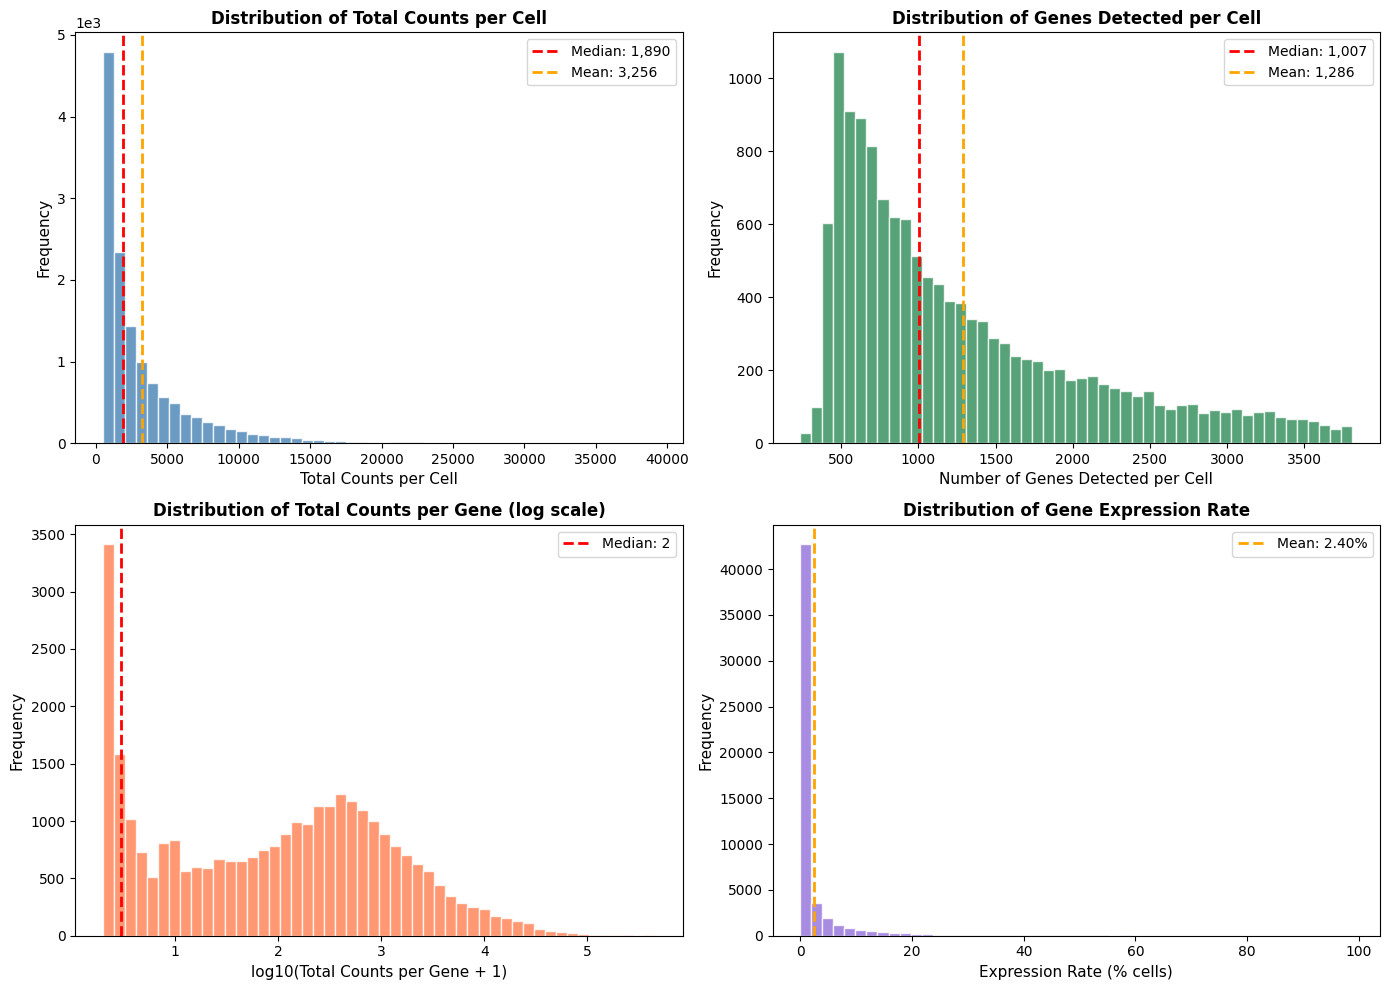

📊 图表已保存: step3_cell_gene_distributions.png


In [12]:
# 绘制细胞和基因统计分布图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 每细胞总表达量分布
ax1 = axes[0, 0]
ax1.hist(n_counts, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(np.median(n_counts), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(n_counts):,.0f}')
ax1.axvline(n_counts.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {n_counts.mean():,.0f}')
ax1.set_xlabel('Total Counts per Cell / 每细胞总表达量', fontsize=11)
ax1.set_ylabel('Frequency / 频率', fontsize=11)
ax1.set_title('Distribution of Total Counts per Cell / 每细胞总表达量分布', fontsize=12, fontweight='bold')
ax1.legend()
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# 2. 每细胞检测到的基因数分布
ax2 = axes[0, 1]
ax2.hist(n_genes, bins=50, color='seagreen', edgecolor='white', alpha=0.8)
ax2.axvline(np.median(n_genes), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(n_genes):,.0f}')
ax2.axvline(n_genes.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {n_genes.mean():,.0f}')
ax2.set_xlabel('Number of Genes Detected per Cell / 每细胞检测基因数', fontsize=11)
ax2.set_ylabel('Frequency / 频率', fontsize=11)
ax2.set_title('Distribution of Genes Detected per Cell / 每细胞检测基因数分布', fontsize=12, fontweight='bold')
ax2.legend()

# 3. 每基因总表达量分布 (log scale)
ax3 = axes[1, 0]
log_gene_counts = np.log10(gene_counts[gene_counts > 0] + 1)
ax3.hist(log_gene_counts, bins=50, color='coral', edgecolor='white', alpha=0.8)
ax3.axvline(np.log10(np.median(gene_counts) + 1), color='red', linestyle='--', linewidth=2, 
            label=f'Median: {np.median(gene_counts):,.0f}')
ax3.set_xlabel('log10(Total Counts per Gene + 1) / log10(每基因总表达量+1)', fontsize=11)
ax3.set_ylabel('Frequency / 频率', fontsize=11)
ax3.set_title('Distribution of Total Counts per Gene (log scale) / 每基因总表达量分布(对数尺度)', fontsize=12, fontweight='bold')
ax3.legend()

# 4. 基因表达率分布
ax4 = axes[1, 1]
ax4.hist(gene_expr_rate * 100, bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
ax4.axvline(gene_expr_rate.mean() * 100, color='orange', linestyle='--', linewidth=2, 
            label=f'Mean: {gene_expr_rate.mean()*100:.2f}%')
ax4.set_xlabel('Expression Rate (% cells) / 基因表达率(%)', fontsize=11)
ax4.set_ylabel('Frequency / 频率', fontsize=11)
ax4.set_title('Distribution of Gene Expression Rate / 基因表达率分布', fontsize=12, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('step3_cell_gene_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step3_cell_gene_distributions.png")

/tmp/ipykernel_3593734/2834297305.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_violin, x='n_genes_group', y='n_counts', ax=ax2, palette='Blues')


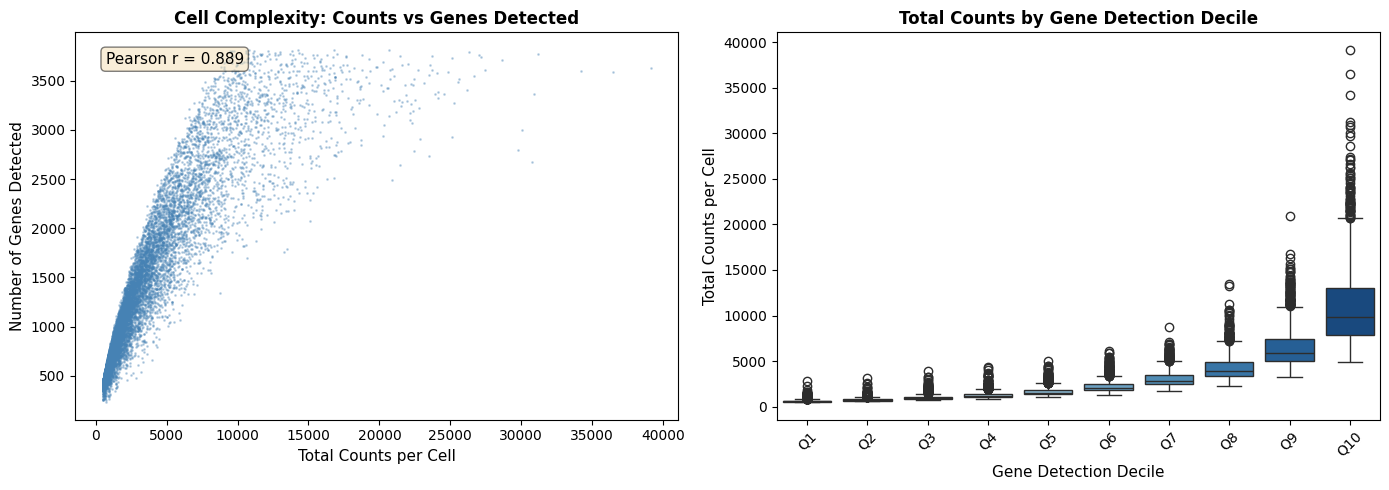

📊 图表已保存: step3_cell_gene_relationship.png


In [13]:
# 细胞-基因表达量关系分析
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. n_counts vs n_genes 散点图
ax1 = axes[0]
ax1.scatter(n_counts, n_genes, alpha=0.3, s=1, c='steelblue')
ax1.set_xlabel('Total Counts per Cell / 每细胞总表达量', fontsize=11)
ax1.set_ylabel('Number of Genes Detected / 检测基因数', fontsize=11)
ax1.set_title('Cell Complexity: Counts vs Genes Detected / 细胞复杂度:表达量vs检测基因数', fontsize=12, fontweight='bold')

# 计算相关系数
corr = np.corrcoef(n_counts, n_genes)[0, 1]
ax1.text(0.05, 0.95, f'Pearson r = {corr:.3f}', , transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. 表达量 vs 基因数箱线图（分位数）
ax2 = axes[1]

# 将细胞按 n_genes 分成 10 个分位数组
groups = pd.qcut(n_genes, q=10, labels=[f'Q{i+1}' for i in range(10)], duplicates='drop')
df_violin = pd.DataFrame({'n_genes_group': groups, 'n_counts': n_counts})

sns.boxplot(data=df_violin, x='n_genes_group', y='n_counts', ax=ax2, palette='Blues')
ax2.set_xlabel('Gene Detection Decile / 基因检测十分位数', fontsize=11)
ax2.set_ylabel('Total Counts per Cell / 每细胞总表达量', fontsize=11)
ax2.set_title('Total Counts by Gene Detection Decile / 按基因检测十分位数统计的总表达量', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('step3_cell_gene_relationship.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step3_cell_gene_relationship.png")

---

## Step 3.5: 稀疏度深度可视化分析 (不降维) <a id="step35"></a>

在不降维的情况下，有多种专门针对稀疏数据的可视化方法：

1. **稀疏矩阵热力图** — 对稀疏矩阵进行空间排序（行/列均值），观察 block 结构
2. **双 Log 曲线** — 验证稀疏度与规模的关系
3. **Rank-Order 曲线** — 按表达量排序基因/细胞，发现幂律分布
4. **稀疏度分层分析** — 按基因/细胞分组，量化各层的稀疏度
5. **矩阵覆盖度曲线** — 逐步增加行/列，观察非零覆盖的增长速度
6. **稀疏度分位数诊断** — 识别异常稀疏或异常密集的细胞/基因

In [14]:
# 为深度稀疏度分析准备数据
# X 已在 Step 3 的 Cell 13 加载到内存，此处复用即可
print("🔄 复用已加载的矩阵 X 进行稀疏度深度分析...")
print(f"   数据规模: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"   矩阵类型: {type(X).__name__}")
print(f"   ✅ nnz: {X.nnz:,}")
sparsity = 1 - X.nnz / (adata.n_obs * adata.n_vars)
print(f"   ✅ 稀疏度: {sparsity:.4%}")

🔄 复用已加载的矩阵 X 进行稀疏度深度分析...
   数据规模: 13,514 cells × 53,678 genes
   矩阵类型: csr_matrix
   ✅ nnz: 17,378,932
   ✅ 稀疏度: 97.6042%


🗺️ 可视化 1: 稀疏矩阵块结构热力图


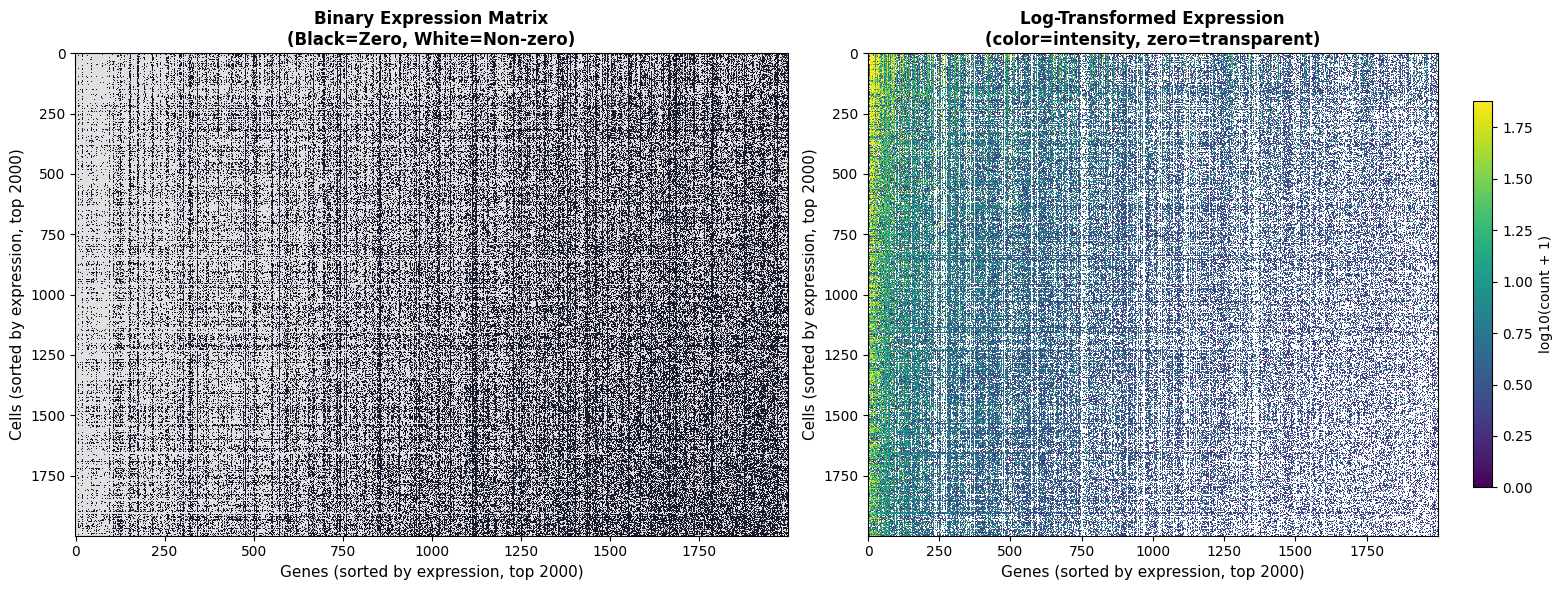

📊 图表已保存: step35_sparsity_heatmap.png

   💡 解读: 左图中白色密集区域表示高表达细胞群/基因群，
      黑色区域表示未检测到表达，可观察是否存在 block/batch 结构。


In [15]:
# ============================================================
# 可视化 1: 稀疏矩阵块结构热力图
# ============================================================
print("=" * 60)
print("🗺️ 可视化 1: 稀疏矩阵块结构热力图")
print("=" * 60)

# 按行/列均值排序
cell_order = np.argsort(np.array(X.sum(axis=1)).flatten())[::-1]
gene_order = np.argsort(np.array(X.sum(axis=0)).flatten())[::-1]

# 采样: 如果矩阵太大，只取部分进行可视化
max_cells_vis = min(adata.n_obs, 2000)
max_genes_vis = min(adata.n_vars, 2000)

X_sorted = X[cell_order[:max_cells_vis]][:, gene_order[:max_genes_vis]]

# 转为密集并二值化
X_binary = (X_sorted > 0).toarray().astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图: 二值热力图 (黑=零, 白=非零)
ax1 = axes[0]
cmap_binary = plt.cm.colors.ListedColormap(['#1a1a2e', '#e0e0e0'])
ax1.imshow(X_binary, aspect='auto', cmap=cmap_binary, interpolation='nearest')
ax1.set_xlabel(f'Genes (sorted, top {max_genes_vis} / 基因(按表达量排序前{max_genes_vis}))', fontsize=11)
ax1.set_ylabel(f'Cells (sorted, top {max_cells_vis} / 细胞(按表达量排序前{max_cells_vis}))', fontsize=11)
ax1.set_title('Binary Expression Matrix / 二值表达矩阵\n(Black=Zero, White=Non-zero)', fontsize=12, fontweight='bold')

# 右图: 对数表达量热力图
ax2 = axes[1]
X_log = X_sorted.toarray()
X_log[X_log == 0] = np.nan
X_log = np.log10(X_log + 1)
vmax = np.nanpercentile(X_log, 99)
im = ax2.imshow(X_log, aspect='auto', cmap='viridis', interpolation='nearest', vmin=0, vmax=vmax)
ax2.set_xlabel(f'Genes (sorted, top {max_genes_vis} / 基因(按表达量排序前{max_genes_vis}))', fontsize=11)
ax2.set_ylabel(f'Cells (sorted, top {max_cells_vis} / 细胞(按表达量排序前{max_cells_vis}))', fontsize=11)
ax2.set_title('Log-Transformed Expression / 对数变换表达量\n(color=intensity, zero=transparent)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax2, label='log10(count + 1)', shrink=0.8)

plt.tight_layout()
plt.savefig('step35_sparsity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step35_sparsity_heatmap.png")
print(f"\n   💡 解读: 左图中白色密集区域表示高表达细胞群/基因群，")
print(f"      黑色区域表示未检测到表达，可观察是否存在 block/batch 结构。")

📐 可视化 2: 双 Log 曲线 — 稀疏度与规模的关系


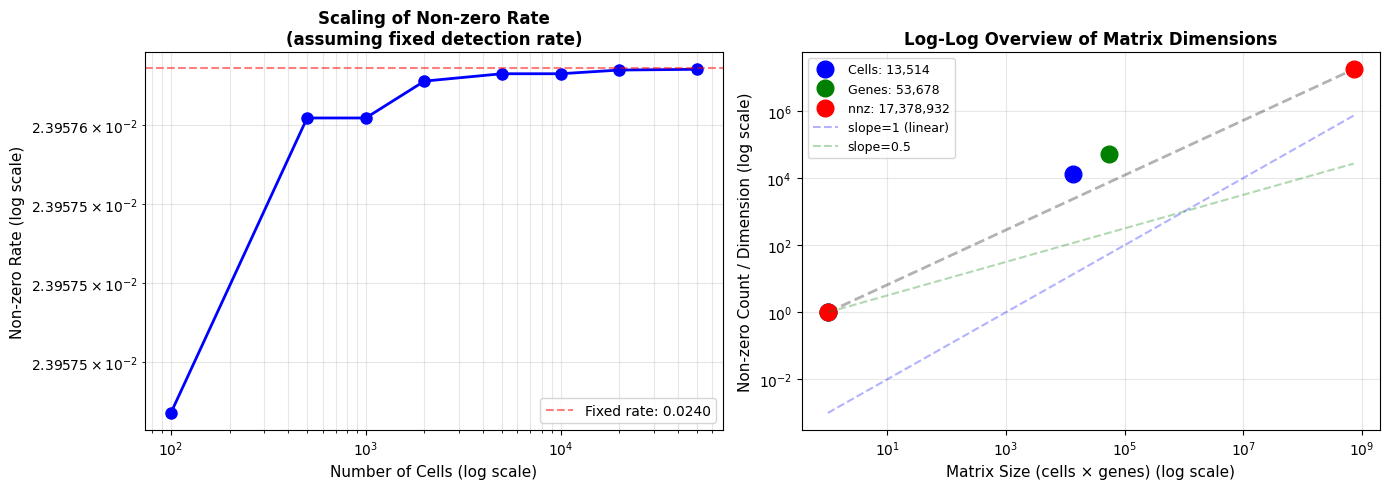

📊 图表已保存: step35_loglog_scaling.png

   💡 解读: 双对数曲线中斜率接近1表示稀疏度基本不随规模变化，
      斜率<1表示越大的矩阵越稀疏（常见于单细胞数据）。


In [16]:
# ============================================================
# 可视化 2: 双 Log 曲线
# ============================================================
print("=" * 60)
print("📐 可视化 2: 双 Log 曲线 — 稀疏度与规模的关系")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 不同规模的理论稀疏度
ax1 = axes[0]
cell_range = np.array([100, 500, 1000, 2000, 5000, 10000, 20000, 50000])
fixed_genes = adata.n_vars
avg_detection_rate = n_genes.mean() / adata.n_vars
nnz_estimated = (cell_range * fixed_genes * avg_detection_rate).astype(int)
sparsity_estimated = 1 - nnz_estimated / (cell_range * fixed_genes)

ax1.loglog(cell_range, 1 - sparsity_estimated, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Cells (log scale) / 细胞数量(对数尺度)', fontsize=11)
ax1.set_ylabel('Non-zero Rate (log scale) / 非零率(对数尺度)', fontsize=11)
ax1.set_title('Scaling of Non-zero Rate / 非零率缩放规律\n(assuming fixed detection rate)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')
ax1.axhline(avg_detection_rate, color='red', linestyle='--', alpha=0.5, label=f'Fixed rate: {avg_detection_rate:.4f}')
ax1.legend()

# 右图: 当前矩阵的 nnz vs 规模的 log-log 可视化
ax2 = axes[1]
current_nnz = X.nnz
current_ncells = adata.n_obs
current_ngenes = adata.n_vars
total_elements = current_ncells * current_ngenes

ax2.loglog([1, total_elements], [1, current_nnz], 'ko--', alpha=0.3, linewidth=2)
ax2.loglog([1, current_ncells], [1, adata.n_obs], 'bo', markersize=12, label=f'Cells: {current_ncells:,}')
ax2.loglog([1, current_ngenes], [1, adata.n_vars], 'go', markersize=12, label=f'Genes: {current_ngenes:,}')
ax2.loglog([1, total_elements], [1, current_nnz], 'ro', markersize=12, label=f'nnz: {current_nnz:,}')

slope_1 = np.array([1, total_elements])
ax2.loglog(slope_1, slope_1 * 1e-3, 'b--', alpha=0.3, label='slope=1 (linear)')
ax2.loglog(slope_1, np.sqrt(slope_1), 'g--', alpha=0.3, label='slope=0.5')

ax2.set_xlabel('Matrix Size (cells × genes) (log scale) / 矩阵规模(细胞×基因)(对数尺度)', fontsize=11)
ax2.set_ylabel('Non-zero Count / Dimension (log scale) / 非零元素数/维度(对数尺度)', fontsize=11)
ax2.set_title('Log-Log Overview of Matrix Dimensions / 矩阵维度的对数-overview', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('step35_loglog_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step35_loglog_scaling.png")
print(f"\n   💡 解读: 双对数曲线中斜率接近1表示稀疏度基本不随规模变化，")
print(f"      斜率<1表示越大的矩阵越稀疏（常见于单细胞数据）。")

📈 可视化 3: Rank-Order 曲线 — 幂律/Zipf 分布


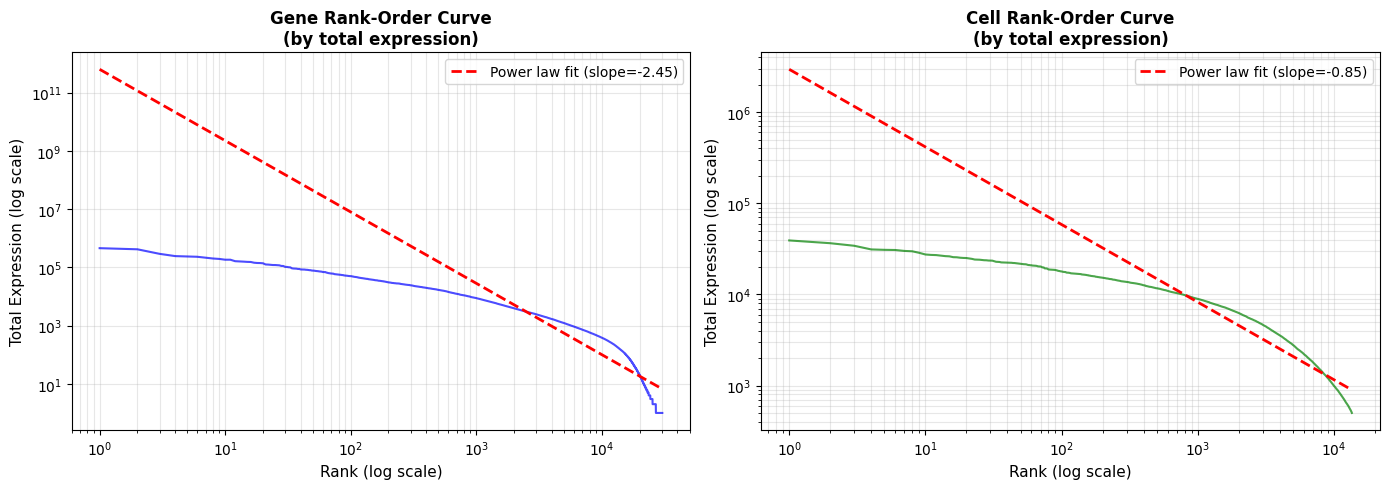

📊 图表已保存: step35_rank_order.png

   📊 基因幂律斜率: -2.45
   📊 细胞幂律斜率: -0.85

   💡 解读: 幂律斜率接近 -1 符合 Zipf 定律，说明表达量分布高度不均匀。
      斜率绝对值越大，说明头部效应越明显。


In [17]:
# ============================================================
# 可视化 3: Rank-Order 曲线 (幂律分布)
# ============================================================
print("=" * 60)
print("📈 可视化 3: Rank-Order 曲线 — 幂律/Zipf 分布")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 基因 Rank-Order
ax1 = axes[0]
gene_total = np.array(X.sum(axis=0)).flatten()
gene_total_sorted = np.sort(gene_total)[::-1]
gene_total_nonzero = gene_total_sorted[gene_total_sorted > 0]
rank_gene = np.arange(1, len(gene_total_nonzero) + 1)

ax1.loglog(rank_gene, gene_total_nonzero, 'b-', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Rank (log scale) / 秩(对数尺度)', fontsize=11)
ax1.set_ylabel('Total Expression (log scale) / 总表达量(对数尺度)', fontsize=11)
ax1.set_title('Gene Rank-Order Curve / 基因秩-序曲线\n(by total expression)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')

# 拟合幂律
log_rank = np.log(rank_gene)
log_expr = np.log(gene_total_nonzero)
slope, intercept = np.polyfit(log_rank, log_expr, 1)
x_fit = np.linspace(1, len(rank_gene), 100)
y_fit = np.exp(intercept) * x_fit ** slope
ax1.loglog(x_fit, y_fit, 'r--', linewidth=2, label=f'Power law fit (slope={slope:.2f})')
ax1.legend()

# 右图: 细胞 Rank-Order
ax2 = axes[1]
cell_total = np.array(X.sum(axis=1)).flatten()
cell_total_sorted = np.sort(cell_total)[::-1]
cell_total_nonzero = cell_total_sorted[cell_total_sorted > 0]
rank_cell = np.arange(1, len(cell_total_nonzero) + 1)

ax2.loglog(rank_cell, cell_total_nonzero, 'g-', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Rank (log scale) / 秩(对数尺度)', fontsize=11)
ax2.set_ylabel('Total Expression (log scale) / 总表达量(对数尺度)', fontsize=11)
ax2.set_title('Cell Rank-Order Curve / 细胞秩-序曲线\n(by total expression)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

log_rank_c = np.log(rank_cell)
log_expr_c = np.log(cell_total_nonzero)
slope_c, intercept_c = np.polyfit(log_rank_c, log_expr_c, 1)
x_fit_c = np.linspace(1, len(rank_cell), 100)
y_fit_c = np.exp(intercept_c) * x_fit_c ** slope_c
ax2.loglog(x_fit_c, y_fit_c, 'r--', linewidth=2, label=f'Power law fit (slope={slope_c:.2f})')
ax2.legend()

plt.tight_layout()
plt.savefig('step35_rank_order.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step35_rank_order.png")
print(f"\n   📊 基因幂律斜率: {slope:.2f}")
print(f"   📊 细胞幂律斜率: {slope_c:.2f}")
print(f"\n   💡 解读: 幂律斜率接近 -1 符合 Zipf 定律，说明表达量分布高度不均匀。")
print(f"      斜率绝对值越大，说明头部效应越明显。")

🔬 可视化 4: 稀疏度分层分析


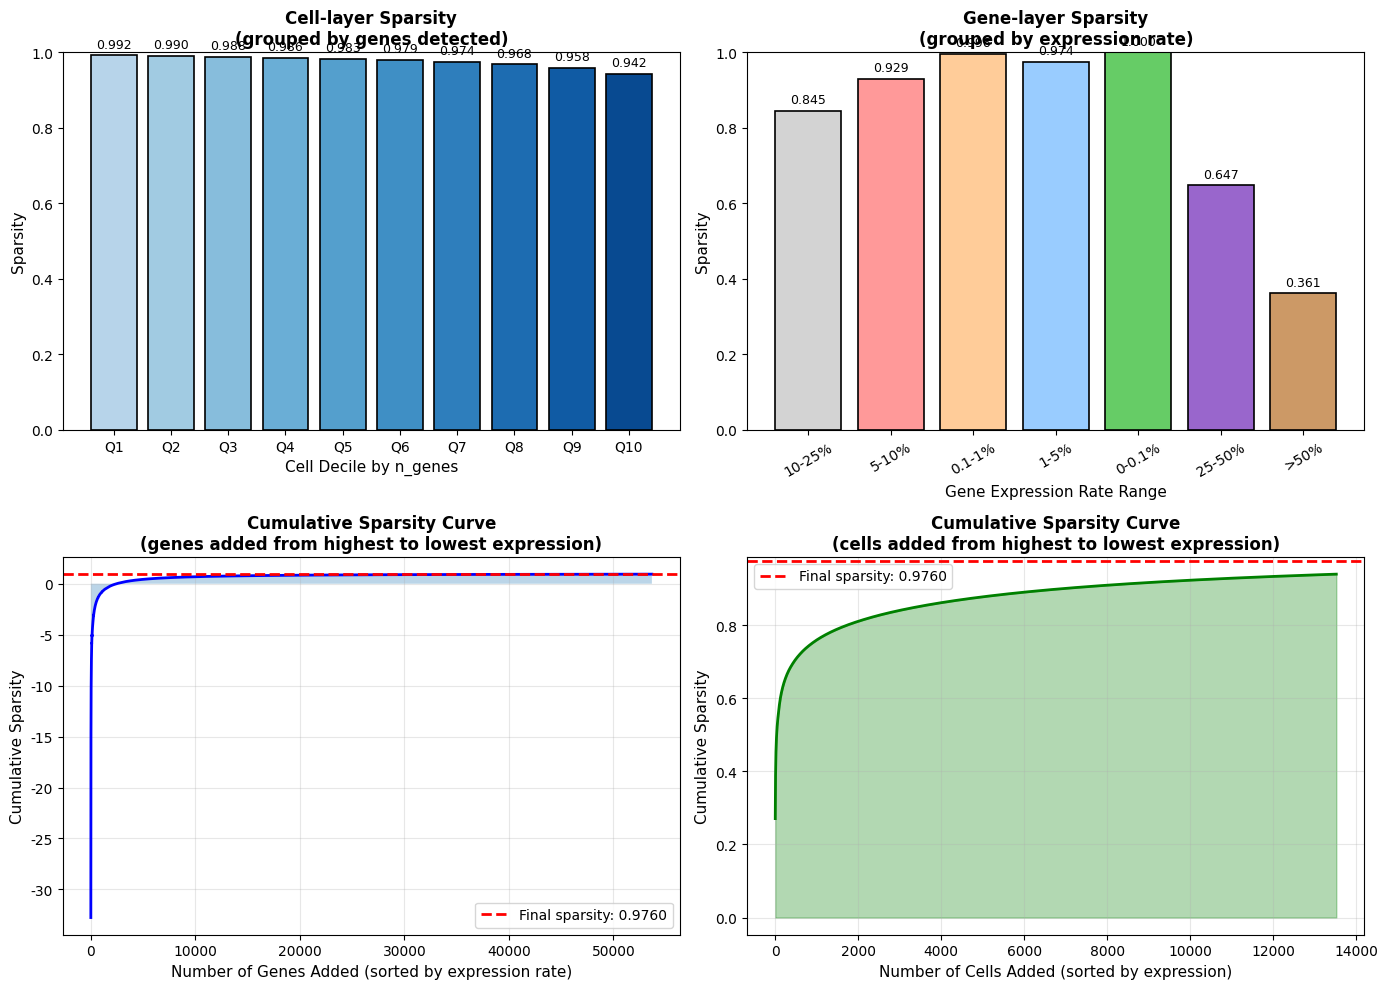

📊 图表已保存: step35_stratified_sparsity.png

   💡 解读: 左上/右上展示不同细胞/基因层的稀疏度差异，
      左下/右下展示按表达量排序后逐步加入行列时稀疏度的累积变化。


In [18]:
# ============================================================
# 可视化 4: 稀疏度分层分析
# ============================================================
print("=" * 60)
print("🔬 可视化 4: 稀疏度分层分析")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 左上: 细胞按 n_genes 分层，每层的稀疏度
ax1 = axes[0, 0]
cell_expr_bins = pd.qcut(n_genes, q=10, labels=False, duplicates='drop')
layer_sparsity_cells = []
layer_labels = []
for i in range(10):
    mask = cell_expr_bins == i
    if mask.sum() > 0:
        X_layer = X[mask]
        layer_nnz = X_layer.nnz
        layer_total = X_layer.shape[0] * X_layer.shape[1]
        layer_sparse = 1 - layer_nnz / layer_total
        layer_sparsity_cells.append(layer_sparse)
        layer_labels.append(f'Q{i+1}')

ax1.bar(layer_labels, layer_sparsity_cells, 
        color=plt.cm.Blues(np.linspace(0.3, 0.9, len(layer_sparsity_cells))),
        edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Cell Decile by n_genes / 按n_genes划分的细胞十分位', fontsize=11)
ax1.set_ylabel('Sparsity / 稀疏度', fontsize=11)
ax1.set_title('Cell-layer Sparsity / 细胞层稀疏度\n(grouped by genes detected)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1)
for i, v in enumerate(layer_sparsity_cells):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 右上: 基因按表达率分层
ax2 = axes[0, 1]
gene_rate_bins = pd.cut(gene_expr_rate, 
                        bins=[0, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0], 
                        labels=['0-0.1%', '0.1-1%', '1-5%', '5-10%', '10-25%', '25-50%', '>50%'],
                        include_lowest=True)
layer_sparsity_genes = []
layer_labels_g = []
for label in gene_rate_bins.unique():
    if pd.isna(label):
        continue
    mask = gene_rate_bins == label
    X_layer = X[:, mask]
    layer_nnz = X_layer.nnz
    layer_total = X_layer.shape[0] * X_layer.shape[1]
    layer_sparse = 1 - layer_nnz / layer_total
    layer_sparsity_genes.append(layer_sparse)
    layer_labels_g.append(str(label))

colors_g = ['#d3d3d3', '#ff9999', '#ffcc99', '#99ccff', '#66cc66', '#9966cc', '#cc9966']
ax2.bar(layer_labels_g, layer_sparsity_genes, color=colors_g[:len(layer_labels_g)],
        edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Gene Expression Rate Range / 基因表达率区间', fontsize=11)
ax2.set_ylabel('Sparsity / 稀疏度', fontsize=11)
ax2.set_title('Gene-layer Sparsity / 基因层稀疏度\n(grouped by expression rate)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=30)
for i, v in enumerate(layer_sparsity_genes):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# 左下: 累积稀疏度曲线 (逐步加入基因)
ax3 = axes[1, 0]
gene_order_by_rate = np.argsort(gene_expr_rate)[::-1]
cumulative_nnz = np.cumsum(np.array(X[:, gene_order_by_rate].sum(axis=0)).flatten())
cumulative_total = np.arange(1, adata.n_vars + 1) * adata.n_obs
cumulative_sparsity = 1 - cumulative_nnz / cumulative_total

ax3.plot(np.arange(1, adata.n_vars + 1), cumulative_sparsity, 'b-', linewidth=2)
ax3.fill_between(np.arange(1, adata.n_vars + 1), cumulative_sparsity, alpha=0.3)
ax3.axhline(sparsity, color='red', linestyle='--', linewidth=2, label=f'Final sparsity: {sparsity:.4f}')
ax3.set_xlabel('Number of Genes Added (sorted by expression rate) / 加入的基因数(按表达率排序)', fontsize=11)
ax3.set_ylabel('Cumulative Sparsity / 累积稀疏度', fontsize=11)
ax3.set_title('Cumulative Sparsity Curve / 累积稀疏度曲线\n(genes added from highest to lowest expression)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 右下: 累积稀疏度曲线 (逐步加入细胞)
ax4 = axes[1, 1]
cell_order_by_expr = np.argsort(n_counts)[::-1]
cumulative_nnz_cells = np.cumsum(np.array(X[cell_order_by_expr].sum(axis=1)).flatten())
cumulative_total_cells = np.arange(1, adata.n_obs + 1) * adata.n_vars
cumulative_sparsity_cells = 1 - cumulative_nnz_cells / cumulative_total_cells

ax4.plot(np.arange(1, adata.n_obs + 1), cumulative_sparsity_cells, 'g-', linewidth=2)
ax4.fill_between(np.arange(1, adata.n_obs + 1), cumulative_sparsity_cells, alpha=0.3, color='green')
ax4.axhline(sparsity, color='red', linestyle='--', linewidth=2, label=f'Final sparsity: {sparsity:.4f}')
ax4.set_xlabel('Number of Cells Added (sorted by expression) / 加入的细胞数(按表达量排序), fontsize=11)
ax4.set_ylabel('Cumulative Sparsity / 累积稀疏度', fontsize=11)
ax4.set_title('Cumulative Sparsity Curve / 累积稀疏度曲线\n(cells added from highest to lowest expression)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step35_stratified_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step35_stratified_sparsity.png")
print(f"\n   💡 解读: 左上/右上展示不同细胞/基因层的稀疏度差异，")
print(f"      左下/右下展示按表达量排序后逐步加入行列时稀疏度的累积变化。")

📊 可视化 5: 矩阵覆盖度曲线


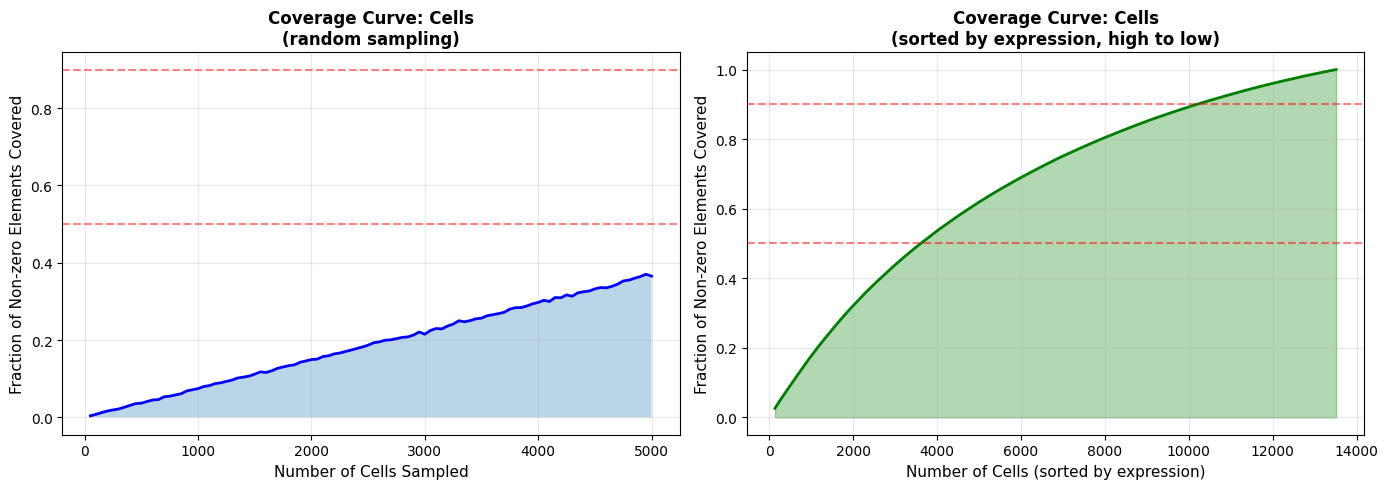

📊 图表已保存: step35_coverage_curve.png

   💡 解读: 覆盖度曲线显示需要多少比例的细胞/基因就能覆盖大部分非零元素。
      曲线陡峭说明少量高表达细胞/基因就包含了大部分信息。


In [19]:
# ============================================================
# 可视化 5: 矩阵覆盖度曲线
# ============================================================
print("=" * 60)
print("📊 可视化 5: 矩阵覆盖度曲线")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 随机采样行/列时的覆盖度增长
ax1 = axes[0]
np.random.seed(42)
n_trials = min(adata.n_obs, 5000)
step_size = max(1, n_trials // 100)

coverage_by_cells = []
for n in range(step_size, n_trials + 1, step_size):
    sampled_cells = np.random.choice(adata.n_obs, n, replace=False)
    X_sample = X[sampled_cells]
    coverage = X_sample.nnz / X.nnz
    coverage_by_cells.append(coverage)

cell_x = np.arange(step_size, n_trials + 1, step_size)

ax1.plot(cell_x, coverage_by_cells, 'b-', linewidth=2)
ax1.fill_between(cell_x, coverage_by_cells, alpha=0.3)
ax1.set_xlabel('Number of Cells Sampled / 采样细胞数', fontsize=11)
ax1.set_ylabel('Fraction of Non-zero Elements Covered / 非零元素覆盖率', fontsize=11)
ax1.set_title('Coverage Curve: Cells / 覆盖度曲线:细胞\n(random sampling)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax1.axhline(0.9, color='red', linestyle='--', alpha=0.5)

# 右图: 按表达量排序后增加细胞
ax2 = axes[1]
cell_order_desc = np.argsort(n_counts)[::-1]
coverage_by_cells_sorted = []
for pct in np.linspace(0.01, 1.0, 100):
    n_cells = max(1, int(pct * adata.n_obs))
    X_sample = X[cell_order_desc[:n_cells]]
    coverage = X_sample.nnz / X.nnz
    coverage_by_cells_sorted.append(coverage)

ax2.plot(np.linspace(0.01, 1.0, 100) * adata.n_obs, coverage_by_cells_sorted, 'g-', linewidth=2)
ax2.fill_between(np.linspace(0.01, 1.0, 100) * adata.n_obs, coverage_by_cells_sorted, alpha=0.3, color='green')
ax2.set_xlabel('Number of Cells (sorted by expression) / 细胞数(按表达量排序)', fontsize=11)
ax2.set_ylabel('Fraction of Non-zero Elements Covered / 非零元素覆盖率', fontsize=11)
ax2.set_title('Coverage Curve: Cells / 覆盖度曲线:细胞\n(sorted by expression, high to low)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax2.axhline(0.9, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('step35_coverage_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step35_coverage_curve.png")
print(f"\n   💡 解读: 覆盖度曲线显示需要多少比例的细胞/基因就能覆盖大部分非零元素。")
print(f"      曲线陡峭说明少量高表达细胞/基因就包含了大部分信息。")

🔍 可视化 6: 稀疏度分位数诊断 — 异常值检测


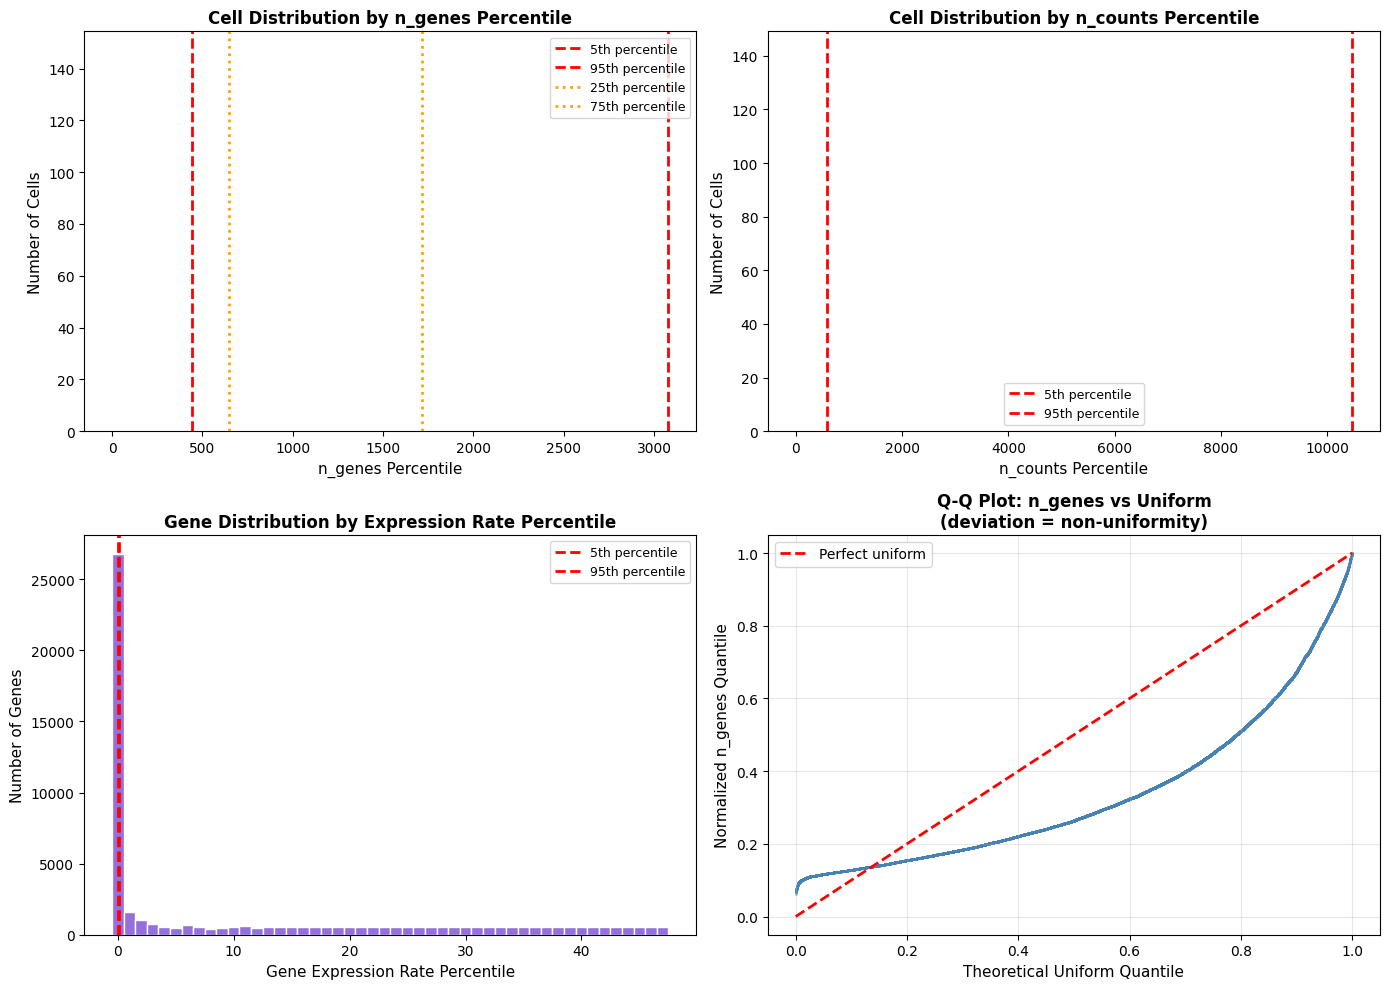

📊 图表已保存: step35_quantile_diagnostics.png

🔎 细胞异常值检测:
   - n_genes 过低 (<5%分位): 673 个细胞 (4.98%)
   - n_genes 过高 (>95%分位): 675 个细胞 (4.99%)
   - n_counts 过低 (<5%分位): 670 个细胞 (4.96%)
   - n_counts 过高 (>95%分位): 676 个细胞 (5.00%)

🔎 基因异常值检测:
   - 完全无表达: 23,332 个基因 (43.47%)
   - 表达率极低 (<5%分位): 23,332 个基因 (43.47%)
   - 表达率极高 (>95%分位): 2,683 个基因 (5.00%)

   💡 解读: 异常值可能代表低质量细胞、doublets 或 housekeeping genes。


In [20]:
# ============================================================
# 可视化 6: 稀疏度分位数诊断
# ============================================================
print("=" * 60)
print("🔍 可视化 6: 稀疏度分位数诊断 — 异常值检测")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 左上: 细胞 n_genes 分位数分布
ax1 = axes[0, 0]
cell_genes_quantiles = pd.qcut(n_genes, q=100, labels=False, duplicates='drop')
quantile_counts = pd.Series(cell_genes_quantiles).value_counts().sort_index()
ax1.bar(quantile_counts.index, quantile_counts.values, color='steelblue', edgecolor='white', width=1)
ax1.axvline(np.percentile(n_genes, 5), color='red', linestyle='--', linewidth=2, label='5th percentile')
ax1.axvline(np.percentile(n_genes, 95), color='red', linestyle='--', linewidth=2, label='95th percentile')
ax1.axvline(np.percentile(n_genes, 25), color='orange', linestyle=':', linewidth=2, label='25th percentile')
ax1.axvline(np.percentile(n_genes, 75), color='orange', linestyle=':', linewidth=2, label='75th percentile')
ax1.set_xlabel('n_genes Percentile / n_genes百分位数', fontsize=11)
ax1.set_ylabel('Number of Cells / 细胞数量', fontsize=11)
ax1.set_title('Cell Distribution by n_genes Percentile / 按n_genes百分位数分布的细胞', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# 右上: 细胞 n_counts 分位数分布
ax2 = axes[0, 1]
cell_counts_quantiles = pd.qcut(n_counts, q=100, labels=False, duplicates='drop')
quantile_counts_c = pd.Series(cell_counts_quantiles).value_counts().sort_index()
ax2.bar(quantile_counts_c.index, quantile_counts_c.values, color='seagreen', edgecolor='white', width=1)
ax2.axvline(np.percentile(n_counts, 5), color='red', linestyle='--', linewidth=2, label='5th percentile')
ax2.axvline(np.percentile(n_counts, 95), color='red', linestyle='--', linewidth=2, label='95th percentile')
ax2.set_xlabel('n_counts Percentile / n_counts百分位数', fontsize=11)
ax2.set_ylabel('Number of Cells / 细胞数量', fontsize=11)
ax2.set_title('Cell Distribution by n_counts Percentile / 按n_counts百分位数分布的细胞', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# 左下: 基因表达率分位数分布
ax3 = axes[1, 0]
gene_rate_quantiles = pd.qcut(gene_expr_rate, q=100, labels=False, duplicates='drop')
quantile_counts_g = pd.Series(gene_rate_quantiles).value_counts().sort_index()
ax3.bar(quantile_counts_g.index, quantile_counts_g.values, color='mediumpurple', edgecolor='white', width=1)
ax3.axvline(np.percentile(gene_expr_rate, 5), color='red', linestyle='--', linewidth=2, label='5th percentile')
ax3.axvline(np.percentile(gene_expr_rate, 95), color='red', linestyle='--', linewidth=2, label='95th percentile')
ax3.set_xlabel('Gene Expression Rate Percentile / 基因表达率百分位数', fontsize=11)
ax3.set_ylabel('Number of Genes / 基因数量', fontsize=11)
ax3.set_title('Gene Distribution by Expression Rate Percentile / 按表达率百分位数分布的基因', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)

# 右下: Q-Q 图
ax4 = axes[1, 1]
n_genes_sorted = np.sort(n_genes)
n_q = len(n_genes_sorted)
theoretical_quantiles = (np.arange(1, n_q + 1) - 0.5) / n_q
ax4.scatter(theoretical_quantiles, n_genes_sorted / n_genes.max(), s=1, alpha=0.5, c='steelblue')
ax4.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect uniform')
ax4.set_xlabel('Theoretical Uniform Quantile / 理论均匀分位数', fontsize=11)
ax4.set_ylabel('Normalized n_genes Quantile / 归一化n_genes分位数', fontsize=11)
ax4.set_title('Q-Q Plot: n_genes vs Uniform / Q-Q图:n_genes与均匀分布\n(deviation = non-uniformity / 偏离度=非均匀性)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step35_quantile_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 图表已保存: step35_quantile_diagnostics.png")

# 打印异常值统计
print(f"\n🔎 细胞异常值检测:")
low_genes_cells = (n_genes < np.percentile(n_genes, 5)).sum()
high_genes_cells = (n_genes > np.percentile(n_genes, 95)).sum()
low_counts_cells = (n_counts < np.percentile(n_counts, 5)).sum()
high_counts_cells = (n_counts > np.percentile(n_counts, 95)).sum()
print(f"   - n_genes 过低 (<5%分位): {low_genes_cells:,} 个细胞 ({low_genes_cells/adata.n_obs*100:.2f}%)")
print(f"   - n_genes 过高 (>95%分位): {high_genes_cells:,} 个细胞 ({high_genes_cells/adata.n_obs*100:.2f}%)")
print(f"   - n_counts 过低 (<5%分位): {low_counts_cells:,} 个细胞 ({low_counts_cells/adata.n_obs*100:.2f}%)")
print(f"   - n_counts 过高 (>95%分位): {high_counts_cells:,} 个细胞 ({high_counts_cells/adata.n_obs*100:.2f}%)")

print(f"\n🔎 基因异常值检测:")
not_expressed_genes = (gene_expr_rate == 0).sum()
low_rate_genes = (gene_expr_rate < np.percentile(gene_expr_rate[gene_expr_rate > 0], 5)).sum()
high_rate_genes = (gene_expr_rate > np.percentile(gene_expr_rate, 95)).sum()
print(f"   - 完全无表达: {not_expressed_genes:,} 个基因 ({not_expressed_genes/adata.n_vars*100:.2f}%)")
print(f"   - 表达率极低 (<5%分位): {low_rate_genes:,} 个基因 ({low_rate_genes/adata.n_vars*100:.2f}%)")
print(f"   - 表达率极高 (>95%分位): {high_rate_genes:,} 个基因 ({high_rate_genes/adata.n_vars*100:.2f}%)")
print(f"\n   💡 解读: 异常值可能代表低质量细胞、doublets 或 housekeeping genes。")

In [21]:
# ============================================================
# 稀疏度综合分析汇总
# ============================================================
print("=" * 60)
print("📋 稀疏度深度分析汇总")
print("=" * 60)

total_matrix_elements = adata.n_obs * adata.n_vars
density = 1 - sparsity

dense_memory_mb = total_matrix_elements * 4 / 1024**2  # float32
sparse_memory_mb = (X.nnz * 8 + (adata.n_obs + 1) * 8 + (adata.n_vars + adata.n_obs) * 8) / 1024**2
compression_ratio = dense_memory_mb / sparse_memory_mb

gene_total_nonzero = np.sort(gene_counts)[::-1]
gene_total_nonzero = gene_total_nonzero[gene_total_nonzero > 0]
top_100_genes_coverage = gene_total_nonzero[:100].sum() / gene_total_nonzero.sum() * 100 if len(gene_total_nonzero) > 0 else 0
top_1000_genes_coverage = gene_total_nonzero[:1000].sum() / gene_total_nonzero.sum() * 100 if len(gene_total_nonzero) > 0 else 0

cell_order_desc = np.argsort(n_counts)[::-1]
top_10pct_cells_nnz = X[cell_order_desc[:max(1, int(0.1 * adata.n_obs))]].nnz
top_10pct_cells_coverage = top_10pct_cells_nnz / X.nnz * 100

print(f"""
【稀疏度核心指标】
{'─' * 55}
  • 矩阵总元素:       {total_matrix_elements:>20,} 个
  • 非零元素数 (nnz): {X.nnz:>20,} 个
  • 精确稀疏度:       {sparsity:>20.6f} ({sparsity*100:.4f}%)
  • 精确密度:         {density:>20.6f} ({density*100:.4f}%)

【内存效率】
{'─' * 55}
  • Dense 内存 (float32):  {dense_memory_mb:>15,.2f} MB
  • Sparse 内存估计:       {sparse_memory_mb:>15,.2f} MB
  • 压缩比:                {compression_ratio:>15.2f}x

【覆盖率】
{'─' * 55}
  • 前 10% 高表达细胞覆盖:  {top_10pct_cells_coverage:>14.2f}% 非零元素
  • 平均每细胞检测基因数:   {n_genes.mean():>15,.0f} 个
  • 平均每基因检测细胞数:   {cells_per_gene.mean():>15,.0f} 个

【异常值检测】
{'─' * 55}
  • 完全无表达基因:  {not_expressed_genes:>10,} 个 ({(not_expressed_genes/adata.n_vars)*100:.2f}%)
  • 低质量细胞 (n_genes<5%分位): {low_genes_cells:>10,} 个 ({(low_genes_cells/adata.n_obs)*100:.2f}%)
  • 高异常细胞 (n_genes>95%分位): {high_genes_cells:>9,} 个 ({(high_genes_cells/adata.n_obs)*100:.2f}%)
""")

print("💡 关键洞察:")
if abs(slope + 1) < 0.3:
    print("   ✅ 基因表达量符合 Zipf 定律（幂律斜率 ≈ -1），分布高度不均匀")
if sparsity > 0.90:
    print("   ✅ 矩阵高度稀疏（>90%为零），非常适合稀疏矩阵存储")
if compression_ratio > 5:
    print(f"   ✅ 稀疏存储可节省 {compression_ratio:.1f}x 内存")
if top_10pct_cells_coverage > 50:
    print(f"   ⚠️  前 10% 高表达细胞包含了 {top_10pct_cells_coverage:.1f}% 的非零元素，数据异质性较高")
if not_expressed_genes / adata.n_vars > 0.5:
    print(f"   ⚠️  {(not_expressed_genes/adata.n_vars)*100:.1f}% 的基因完全无表达，考虑过滤")

print(f"\n📊 所有稀疏度可视化图表已保存:")
print(f"   - step35_sparsity_heatmap.png     (稀疏矩阵块结构)")
print(f"   - step35_loglog_scaling.png        (双对数尺度分析)")
print(f"   - step35_rank_order.png            (幂律/Rank分布)")
print(f"   - step35_stratified_sparsity.png   (分层稀疏度)")
print(f"   - step35_coverage_curve.png        (覆盖度曲线)")
print(f"   - step35_quantile_diagnostics.png   (分位数诊断)")

📋 稀疏度深度分析汇总

【稀疏度核心指标】
───────────────────────────────────────────────────────
  • 矩阵总元素:                725,404,492 个
  • 非零元素数 (nnz):           17,378,932 个
  • 精确稀疏度:                   0.976042 (97.6042%)
  • 精确密度:                     0.023958 (2.3958%)

【内存效率】
───────────────────────────────────────────────────────
  • Dense 内存 (float32):         2,767.20 MB
  • Sparse 内存估计:                133.21 MB
  • 压缩比:                          20.77x

【覆盖率】
───────────────────────────────────────────────────────
  • 前 10% 高表达细胞覆盖:           23.05% 非零元素
  • 平均每细胞检测基因数:             1,286 个
  • 平均每基因检测细胞数:               324 个

【异常值检测】
───────────────────────────────────────────────────────
  • 完全无表达基因:      23,332 个 (43.47%)
  • 低质量细胞 (n_genes<5%分位):        673 个 (4.98%)
  • 高异常细胞 (n_genes>95%分位):       675 个 (4.99%)

💡 关键洞察:
   ✅ 矩阵高度稀疏（>90%为零），非常适合稀疏矩阵存储
   ✅ 稀疏存储可节省 20.8x 内存

📊 所有稀疏度可视化图表已保存:
   - step35_sparsity_heatmap.png     (稀疏矩阵块结构)
   - step35_loglog_scaling.png        (双对数尺度分析)
   - s

---

## Step 4: 细胞元数据 (obs) 探索 <a id="step4"></a>

In [22]:
# obs DataFrame 基本信息
print("=" * 60)
print("📋 细胞元数据 (obs) 探索")
print("=" * 60)

print(f"\n🔍 obs DataFrame 形状: {adata.obs.shape}")
print(f"   行数 (细胞数): {adata.obs.shape[0]:,}")
print(f"   列数 (属性数): {adata.obs.shape[1]}")

print("\n📝 obs 列名及数据类型:")
print("-" * 50)
for col in adata.obs.columns:
    dtype = adata.obs[col].dtype
    n_unique = adata.obs[col].nunique()
    n_null = adata.obs[col].isnull().sum()
    print(f"   {col:30s} | {str(dtype):12s} | unique: {n_unique:>6,} | null: {n_null}")

📋 细胞元数据 (obs) 探索

🔍 obs DataFrame 形状: (13514, 13)
   行数 (细胞数): 13,514
   列数 (属性数): 13

📝 obs 列名及数据类型:
--------------------------------------------------
   Orig.ident                     | object       | unique:      1 | null: 0
   nCount_RNA                     | float64      | unique:  5,778 | null: 0
   nFeature_RNA                   | int32        | unique:  2,969 | null: 0
   Percent.mt                     | float64      | unique:     66 | null: 0
   Seurat_clusters                | object       | unique:     24 | null: 0
   Celltype                       | object       | unique:     15 | null: 0
   Dataset                        | object       | unique:      1 | null: 0
   Tissue                         | object       | unique:      1 | null: 0
   Organ                          | object       | unique:      1 | null: 0
   Condition                      | object       | unique:      1 | null: 0
   Genotype                       | object       | unique:      1 | null: 0
   Librarie

In [23]:
# obs 数据预览
print("\n📊 obs 数据预览 (前10行):")
display(adata.obs.head(10))


📊 obs 数据预览 (前10行):


,Orig.ident,nCount_RNA,nFeature_RNA,Percent.mt,Seurat_clusters,Celltype,Dataset,Tissue,Organ,Condition,Genotype,Libraries,ACE
SRX5290443@@_AAACCTGAGAATTCCC-1,SRX5290443,3737.0,2149,0.0,2,Root stele,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGAGACTTTCG-1,SRX5290443,964.0,747,0.0,14,Root hair,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGAGCTGTTCA-1,SRX5290443,1308.0,881,0.0,14,Root hair,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGAGGTAGCCA-1,SRX5290443,1131.0,790,0.0,5,Root hair,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGAGTAATCCC-1,SRX5290443,2451.0,1290,0.0,5,Root hair,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGAGTACGTTC-1,SRX5290443,6436.0,2416,0.0,5,Root hair,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGAGTATTGGA-1,SRX5290443,3859.0,1905,0.0,12,G2/M phase,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGCAAAGGAAG-1,SRX5290443,2564.0,1263,0.0,22,S phase,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGCACATGACT-1,SRX5290443,1511.0,936,0.0,3,Root stele,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling
SRX5290443@@_AAACCTGCACTACAGT-1,SRX5290443,1240.0,738,0.0,5,Root hair,SRP182008,Root tip,Root,Normal,Col-0,10x Genomics,10 days old seedling


In [24]:
# obs 中的数值型列统计
print("\n📈 obs 中的数值型列统计:")
print("-" * 50)

numeric_cols = adata.obs.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(adata.obs[numeric_cols].describe().round(2))
else:
    print("   未找到数值型列")


📈 obs 中的数值型列统计:
--------------------------------------------------
       nCount_RNA  nFeature_RNA  Percent.mt
count    13514.00      13514.00    13514.00
mean      3255.99       1285.99        0.00
std       3538.86        819.41        0.00
min        500.00        234.00        0.00
25%        968.00        646.00        0.00
50%       1889.50       1007.00        0.00
75%       4166.00       1714.00        0.00
max      39150.00       3812.00        0.15


In [25]:
# 分类/字符串列分析
print("\n🏷️ obs 中的分类/字符串型列分析:")
print("-" * 50)

cat_cols = adata.obs.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    n_unique = adata.obs[col].nunique()
    print(f"\n   【{col}】")
    print(f"   唯一值数量: {n_unique}")
    
    if n_unique <= 20:
        value_counts = adata.obs[col].value_counts()
        print(f"   分布:")
        for val, count in value_counts.items():
            pct = count / len(adata.obs) * 100
            print(f"      {val}: {count:,} ({pct:.1f}%)")
    else:
        value_counts = adata.obs[col].value_counts().head(10)
        print(f"   分布 (前10个):")
        for val, count in value_counts.items():
            pct = count / len(adata.obs) * 100
            print(f"      {val}: {count:,} ({pct:.1f}%)")
        print(f"      ... (共 {n_unique} 个唯一值)")


🏷️ obs 中的分类/字符串型列分析:
--------------------------------------------------

   【Orig.ident】
   唯一值数量: 1
   分布:
      SRX5290443: 13,514 (100.0%)

   【Seurat_clusters】
   唯一值数量: 24
   分布 (前10个):
      0: 1,524 (11.3%)
      1: 1,480 (11.0%)
      2: 1,477 (10.9%)
      3: 1,092 (8.1%)
      4: 1,082 (8.0%)
      5: 809 (6.0%)
      6: 690 (5.1%)
      7: 571 (4.2%)
      8: 511 (3.8%)
      9: 396 (2.9%)
      ... (共 24 个唯一值)

   【Celltype】
   唯一值数量: 15
   分布:
      Root stele: 2,569 (19.0%)
      Root cortex: 1,751 (13.0%)
      Phloem/Pericycle: 1,524 (11.3%)
      Root hair: 1,153 (8.5%)
      Columella root cap: 1,082 (8.0%)
      Lateral root cap: 948 (7.0%)
      Root endodermis: 854 (6.3%)
      Unknow: 805 (6.0%)
      Companion cell: 690 (5.1%)
      S phase: 478 (3.5%)
      Protoxylem: 396 (2.9%)
      G2/M phase: 354 (2.6%)
      Sieve element: 344 (2.5%)
      Metaxylem: 300 (2.2%)
      Root epidermis: 266 (2.0%)

   【Dataset】
   唯一值数量: 1
   分布:
      SRP182008: 13,514 (100.

In [26]:
# 识别标签列（细胞类型标签）
print("\n🎯 细胞类型标签分析:")
print("-" * 50)

label_candidates = ['cell_type', 'CellType', 'celltype', 'cell_type', 
                   'label', 'Label', 'cell_label', 'celltype.coarse',
                   'cell_label', 'cell_type_abbr', 'cluster', 'Cluster',
                   'cell_type_v2', 'cell_type.original']

found_labels = [col for col in adata.obs.columns if col in label_candidates or ('cell' in col.lower() and 'type' in col.lower())]

if found_labels:
    for label_col in found_labels:
        print(f"\n   ✅ 发现细胞类型列: {label_col}")
        value_counts = adata.obs[label_col].value_counts()
        print(f"   唯一类型数: {len(value_counts)}")
        print(f"   分布:")
        for val, count in value_counts.items():
            pct = count / len(adata.obs) * 100
            print(f"      {val}: {count:,} ({pct:.1f}%)")
else:
    print("\n   ⚠️ 未找到明显的细胞类型列")
    print("   可能的标签列:")
    for col in cat_cols[:5]:
        print(f"      - {col}")


🎯 细胞类型标签分析:
--------------------------------------------------

   ✅ 发现细胞类型列: Celltype
   唯一类型数: 15
   分布:
      Root stele: 2,569 (19.0%)
      Root cortex: 1,751 (13.0%)
      Phloem/Pericycle: 1,524 (11.3%)
      Root hair: 1,153 (8.5%)
      Columella root cap: 1,082 (8.0%)
      Lateral root cap: 948 (7.0%)
      Root endodermis: 854 (6.3%)
      Unknow: 805 (6.0%)
      Companion cell: 690 (5.1%)
      S phase: 478 (3.5%)
      Protoxylem: 396 (2.9%)
      G2/M phase: 354 (2.6%)
      Sieve element: 344 (2.5%)
      Metaxylem: 300 (2.2%)
      Root epidermis: 266 (2.0%)


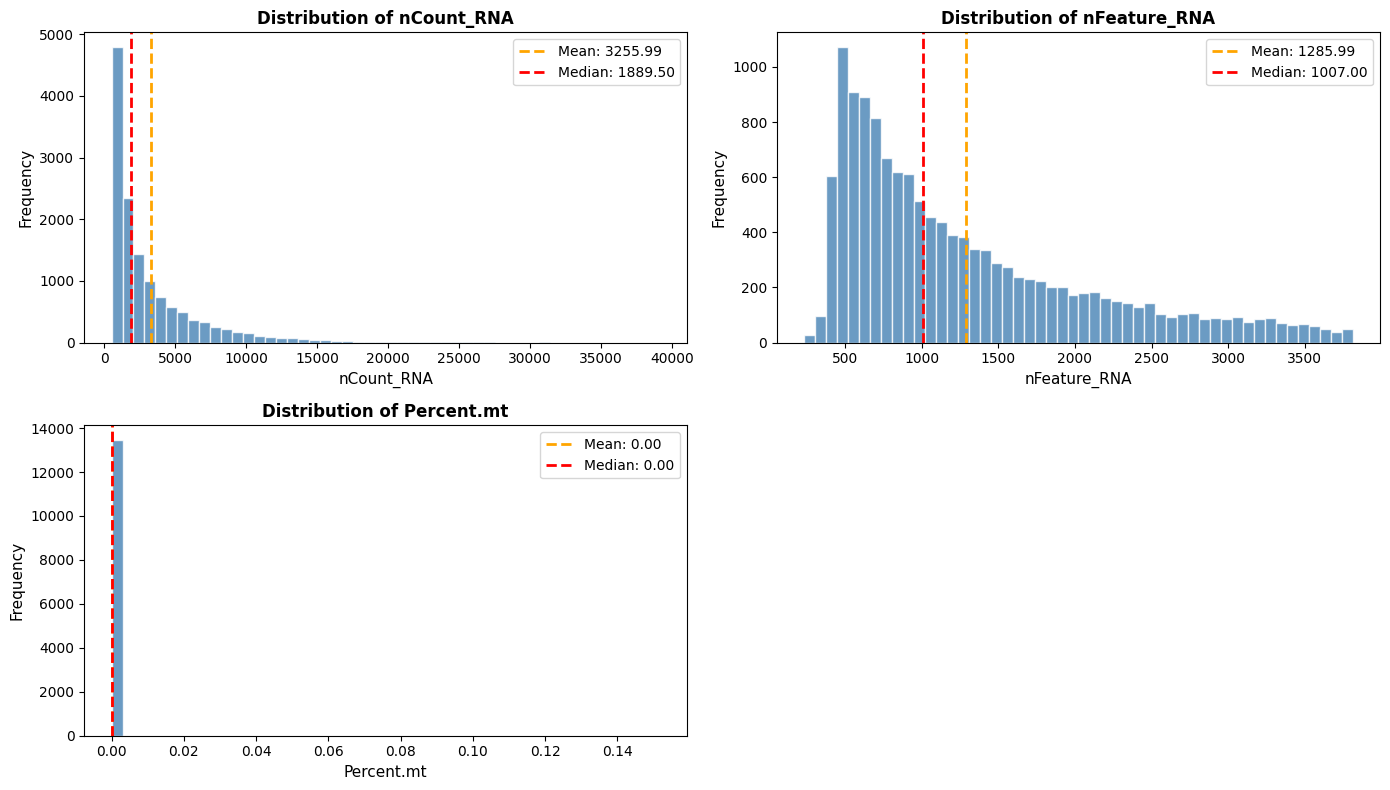

📊 图表已保存: step4_obs_distributions.png


In [27]:
# 可视化 obs 中的关键数值分布
if numeric_cols:
    n_plots = len(numeric_cols)
    n_rows = (n_plots + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        ax.hist(adata.obs[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel('Frequency / 频率', fontsize=11)
        ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        mean_val = adata.obs[col].mean()
        median_val = adata.obs[col].median()
        ax.axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        ax.legend()
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('step4_obs_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 图表已保存: step4_obs_distributions.png")
else:
    print("⚠️ 未找到数值型列进行可视化")

---

## Step 5: 基因元数据 (var) 探索 <a id="step5"></a>

In [28]:
# var DataFrame 基本信息
print("=" * 60)
print("🧬 基因元数据 (var) 探索")
print("=" * 60)

print(f"\n🔍 var DataFrame 形状: {adata.var.shape}")
print(f"   行数 (基因数): {adata.var.shape[0]:,}")
print(f"   列数 (属性数): {adata.var.shape[1]}")

print("\n📝 var 列名及数据类型:")
print("-" * 50)
for col in adata.var.columns:
    dtype = adata.var[col].dtype
    n_unique = adata.var[col].nunique()
    n_null = adata.var[col].isnull().sum()
    print(f"   {col:30s} | {str(dtype):12s} | unique: {n_unique:>6,} | null: {n_null}")

🧬 基因元数据 (var) 探索

🔍 var DataFrame 形状: (53678, 1)
   行数 (基因数): 53,678
   列数 (属性数): 1

📝 var 列名及数据类型:
--------------------------------------------------
   features                       | object       | unique: 53,678 | null: 0


In [29]:
# var 数据预览
print("\n📊 var 数据预览 (前10行):")
display(adata.var.head(10))


📊 var 数据预览 (前10行):


,features
AT1G01010,AT1G01010
AT1G01020,AT1G01020
AT1G01030,AT1G01030
AT1G01040,AT1G01040
AT1G01046,AT1G01046
AT1G01050,AT1G01050
AT1G01060,AT1G01060
AT1G01070,AT1G01070
AT1G01080,AT1G01080
AT1G01090,AT1G01090


In [30]:
# 查找基因名称相关列
print("\n🧬 基因名称列分析:")
print("-" * 50)

gene_name_candidates = ['gene_name', 'GeneName', 'gene_names', 'gene_symbol', 
                        'gene', 'Gene', 'gene_id', 'GeneID', 'gene_short_name']

found_gene_cols = [col for col in adata.var.columns if col in gene_name_candidates or ('gene' in col.lower() and 'name' in col.lower())]

if found_gene_cols:
    for gene_col in found_gene_cols:
        print(f"\n   ✅ 发现基因名称列: {gene_col}")
        print(f"   唯一基因数: {adata.var[gene_col].nunique():,}")
        print(f"   示例基因名:")
        print(f"      {adata.var[gene_col].head(10).tolist()}")
else:
    print("\n   ⚠️ 未找到明显的基因名称列")
    print("   现有列:")
    for col in adata.var.columns[:5]:
        print(f"      - {col}")


🧬 基因名称列分析:
--------------------------------------------------

   ⚠️ 未找到明显的基因名称列
   现有列:
      - features


In [31]:
# var 中的数值型列
print("\n📈 var 中的数值型列统计:")
print("-" * 50)

var_numeric_cols = adata.var.select_dtypes(include=[np.number]).columns.tolist()
if var_numeric_cols:
    print(adata.var[var_numeric_cols].describe().round(2))
else:
    print("   未找到数值型列")


📈 var 中的数值型列统计:
--------------------------------------------------
   未找到数值型列


In [32]:
# 高表达基因 Top 20
print("\n🔥 高表达基因 Top 20:")
print("-" * 50)

adata.var['expr_rate'] = gene_expr_rate
adata.var['total_counts'] = gene_counts

top_genes = adata.var.nlargest(20, 'total_counts')

gene_name_col = found_gene_cols[0] if found_gene_cols else 'index'

print(f"{'Rank':<6} {'Gene':<20} {'Expr Rate':<12} {'Total Counts':<15}")
print("-" * 53)
for i, (idx, row) in enumerate(top_genes.iterrows()):
    gene_name = row[gene_name_col] if gene_name_col in row else idx
    gene_name = str(gene_name)[:18]
    print(f"{i+1:<6} {gene_name:<20} {row['expr_rate']*100:>8.2f}%   {row['total_counts']:>15,.0f}")


🔥 高表达基因 Top 20:
--------------------------------------------------
Rank   Gene                 Expr Rate    Total Counts   
-----------------------------------------------------
1      AT2G47730               98.86%           456,278
2      AT1G07590               96.48%           417,492
3      AT1G78380               97.00%           291,557
4      AT2G22470               87.19%           243,673
5      AT5G42980               95.09%           236,064
6      AT5G02380               63.86%           231,050
7      AT1G66580               92.84%           215,269
8      AT5G64310               84.02%           201,468
9      AT1G76180               92.44%           194,577
10     AT1G75750               63.73%           183,258
11     AT4G11600               89.94%           183,216
12     AT3G09260               75.43%           162,972
13     AT1G76680               88.01%           160,485
14     AT1G45145               84.16%           157,406
15     AT5G11740               86.58%


🧬 基因表达特性分类:
--------------------------------------------------

Category                         Count   Percentage
-------------------------------------------------
Not expressed (0%)              23,332       43.47%
Rare (0-1%)                     16,397       30.55%
Low (1-5%)                       7,676       14.30%
Medium (5-25%)                   5,087        9.48%
High (>25%)                      1,186        2.21%


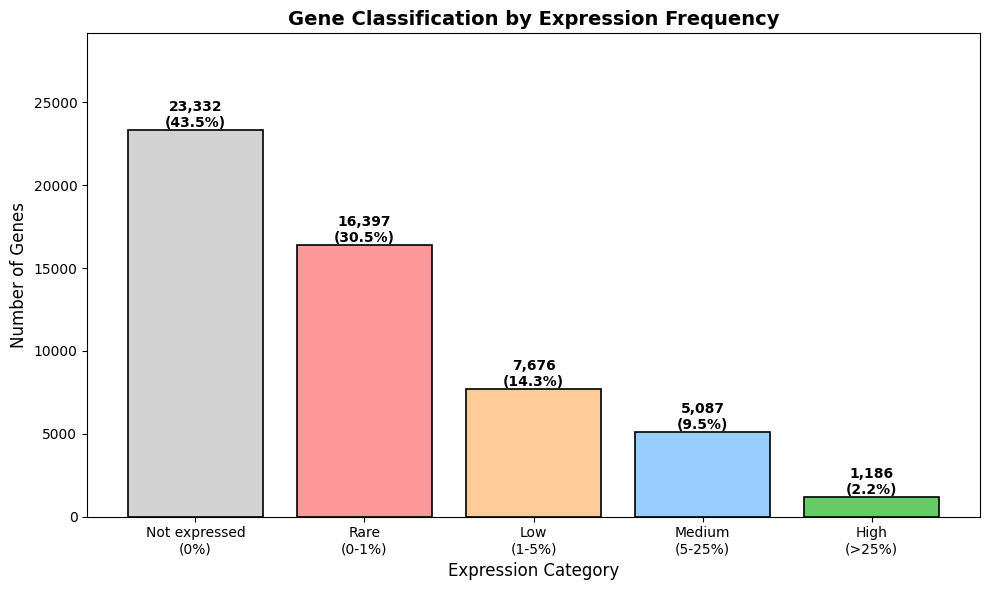


📊 图表已保存: step5_gene_classification.png


In [33]:
# 基因表达特性分类
print("\n🧬 基因表达特性分类:")
print("-" * 50)

total_genes = adata.n_vars  # 避免覆盖 Cell 14 中的 n_genes 数组变量

not_expressed = (gene_expr_rate == 0).sum()
rare_genes = ((gene_expr_rate > 0) & (gene_expr_rate < 0.01)).sum()
low_genes = ((gene_expr_rate >= 0.01) & (gene_expr_rate < 0.05)).sum()
medium_genes = ((gene_expr_rate >= 0.05) & (gene_expr_rate < 0.25)).sum()
high_genes = (gene_expr_rate >= 0.25).sum()

print(f"\n{'Category':<25} {'Count':>12} {'Percentage':>12}")
print("-" * 49)
print(f"{'Not expressed (0%)':<25} {not_expressed:>12,} {not_expressed/total_genes*100:>11.2f}%")
print(f"{'Rare (0-1%)':<25} {rare_genes:>12,} {rare_genes/total_genes*100:>11.2f}%")
print(f"{'Low (1-5%)':<25} {low_genes:>12,} {low_genes/total_genes*100:>11.2f}%")
print(f"{'Medium (5-25%)':<25} {medium_genes:>12,} {medium_genes/total_genes*100:>11.2f}%")
print(f"{'High (>25%)':<25} {high_genes:>12,} {high_genes/total_genes*100:>11.2f}%")

fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Not expressed\n(0%)', 'Rare\n(0-1%)', 'Low\n(1-5%)', 
             'Medium\n(5-25%)', 'High\n(>25%)']
counts = [not_expressed, rare_genes, low_genes, medium_genes, high_genes]
colors = ['#d3d3d3', '#ff9999', '#ffcc99', '#99ccff', '#66cc66']

bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.2)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({count/total_genes*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Expression Category / 表达类别', fontsize=12)
ax.set_ylabel('Number of Genes / 基因数量', fontsize=12)
ax.set_title('Gene Classification by Expression Frequency / 基因表达频率分类', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.25)

plt.tight_layout()
plt.savefig('step5_gene_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: step5_gene_classification.png")

---

## Step 6: 非结构化数据 (uns) 探索 <a id="step6"></a>

In [34]:
# uns 字典探索
print("=" * 60)
print("📦 非结构化数据 (uns) 探索")
print("=" * 60)

if hasattr(adata, 'uns') and adata.uns:
    print(f"\n🔍 uns 包含 {len(adata.uns)} 个键")
    print("\n📋 uns 键列表:")
    print("-" * 50)
    
    for key in adata.uns.keys():
        val = adata.uns[key]
        val_type = type(val).__name__
        
        if isinstance(val, (str, int, float, bool)):
            print(f"   {key:30s} : {val_type:<15} = {val}")
        elif isinstance(val, list):
            print(f"   {key:30s} : {val_type:<15} (len={len(val)})")
            if len(val) <= 10:
                for item in val:
                    print(f"      - {item}")
        elif isinstance(val, dict):
            print(f"   {key:30s} : {val_type:<15} (keys={list(val.keys())[:5]}...)")
        elif isinstance(val, np.ndarray):
            print(f"   {key:30s} : ndarray {val.shape}")
        else:
            print(f"   {key:30s} : {val_type}")
else:
    print("\n⚠️ uns 字典为空或不存在")

📦 非结构化数据 (uns) 探索

⚠️ uns 字典为空或不存在


In [35]:
# 深入探索 uns 中的重要键
print("\n📊 uns 详细内容分析:")
print("-" * 50)

important_keys = ['title', 'batch', 'dataset', 'organism', 'technology', 
                  'pca', 'knn', 'neighbors', 'umap', 'louvain', 'leiden']

for key in adata.uns.keys():
    if any(imp in key.lower() for imp in important_keys):
        print(f"\n   【{key}】")
        val = adata.uns[key]
        
        if isinstance(val, dict):
            for sub_key, sub_val in val.items():
                if isinstance(sub_val, (str, int, float, bool)):
                    print(f"      {sub_key}: {sub_val}")
                elif isinstance(sub_val, np.ndarray):
                    print(f"      {sub_key}: ndarray {sub_val.shape}")
                elif isinstance(sub_val, list):
                    if len(sub_val) <= 5:
                        print(f"      {sub_key}: {sub_val}")
                    else:
                        print(f"      {sub_key}: list of {len(sub_val)} items")
                else:
                    print(f"      {sub_key}: {type(sub_val).__name__}")
        else:
            print(f"      值: {val}")


📊 uns 详细内容分析:
--------------------------------------------------


---

## Step 7: 降维嵌入 (obsm) 探索 <a id="step7"></a>

In [36]:
# obsm (多维嵌入) 探索
print("=" * 60)
print("🎯 降维嵌入 (obsm) 探索")
print("=" * 60)

if hasattr(adata, 'obsm') and adata.obsm:
    print(f"\n🔍 obsm 包含 {len(adata.obsm)} 个嵌入")
    print("\n📋 可用的降维嵌入:")
    print("-" * 50)
    
    for key in adata.obsm.keys():
        arr = adata.obsm[key]
        print(f"   {key:25s}: shape = {arr.shape}")
        
        if 'pca' in key.lower():
            print(f"      → PCA 降维结果")
        elif 'umap' in key.lower():
            print(f"      → UMAP 降维结果")
        elif 'tsne' in key.lower():
            print(f"      → t-SNE 降维结果")
        elif 'diffmap' in key.lower():
            print(f"      → Diffusion Map")
        else:
            print(f"      → 可能的自定义嵌入")
else:
    print("\n⚠️ obsm 为空或不存在")

🎯 降维嵌入 (obsm) 探索

🔍 obsm 包含 2 个嵌入

📋 可用的降维嵌入:
--------------------------------------------------
   X_tsne                   : shape = (13514, 3)
      → t-SNE 降维结果
   X_umap                   : shape = (13514, 2)
      → UMAP 降维结果



📊 可视化 2D 嵌入: ['X_umap']


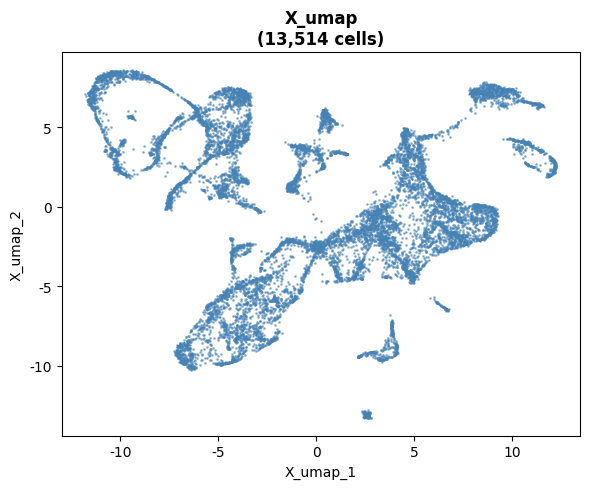

📊 图表已保存: step7_reduction_embeddings.png


In [37]:
# 可视化可用的降维结果
if hasattr(adata, 'obsm') and adata.obsm:
    available_2d = [key for key in adata.obsm.keys() if adata.obsm[key].shape[1] == 2]
    
    if available_2d:
        print(f"\n📊 可视化 2D 嵌入: {available_2d}")
        
        label_col = None
        for col in ['cell_type', 'celltype', 'label', 'Cluster', 'cluster']:
            if col in adata.obs.columns:
                label_col = col
                break
        
        n_plots = len(available_2d)
        fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
        if n_plots == 1:
            axes = [axes]
        
        for i, key in enumerate(available_2d):
            ax = axes[i]
            coords = adata.obsm[key]
            
            if label_col:
                labels = adata.obs[label_col].astype(str)
                unique_labels = labels.unique()
                colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
                
                for j, label in enumerate(unique_labels):
                    mask = labels == label
                    ax.scatter(coords[mask, 0], coords[mask, 1], 
                              c=[colors[j]], label=label[:15], 
                              s=1, alpha=0.5)
                ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                         fontsize=8, markerscale=10)
            else:
                ax.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.5, c='steelblue')
            
            ax.set_xlabel(f'{key}_1')
            ax.set_ylabel(f'{key}_2')
            ax.set_title(f'{key}\n({adata.n_obs:,} cells / 细胞)', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('step7_reduction_embeddings.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("📊 图表已保存: step7_reduction_embeddings.png")
    else:
        print("\n⚠️ 未找到 2D 嵌入")
else:
    print("⚠️ 无可用的降维嵌入")

In [38]:
# varm 分析
print("\n🎯 降维嵌入 (varm) 探索")
print("-" * 50)

if hasattr(adata, 'varm') and adata.varm:
    print(f"varm 包含 {len(adata.varm)} 个嵌入")
    print("\n📋 可用的基因嵌入:")
    
    for key in adata.varm.keys():
        arr = adata.varm[key]
        print(f"   {key:25s}: shape = {arr.shape}")
        if 'PCs' in key:
            print(f"      → 基因 PCA 主成分 (用于解释方差)")
else:
    print("varm 为空或不存在")


🎯 降维嵌入 (varm) 探索
--------------------------------------------------
varm 为空或不存在


---

## Step 8: 数据统计与分布可视化 <a id="step8"></a>

📊 综合数据统计可视化


ValueError: Input array must be 1 dimensional

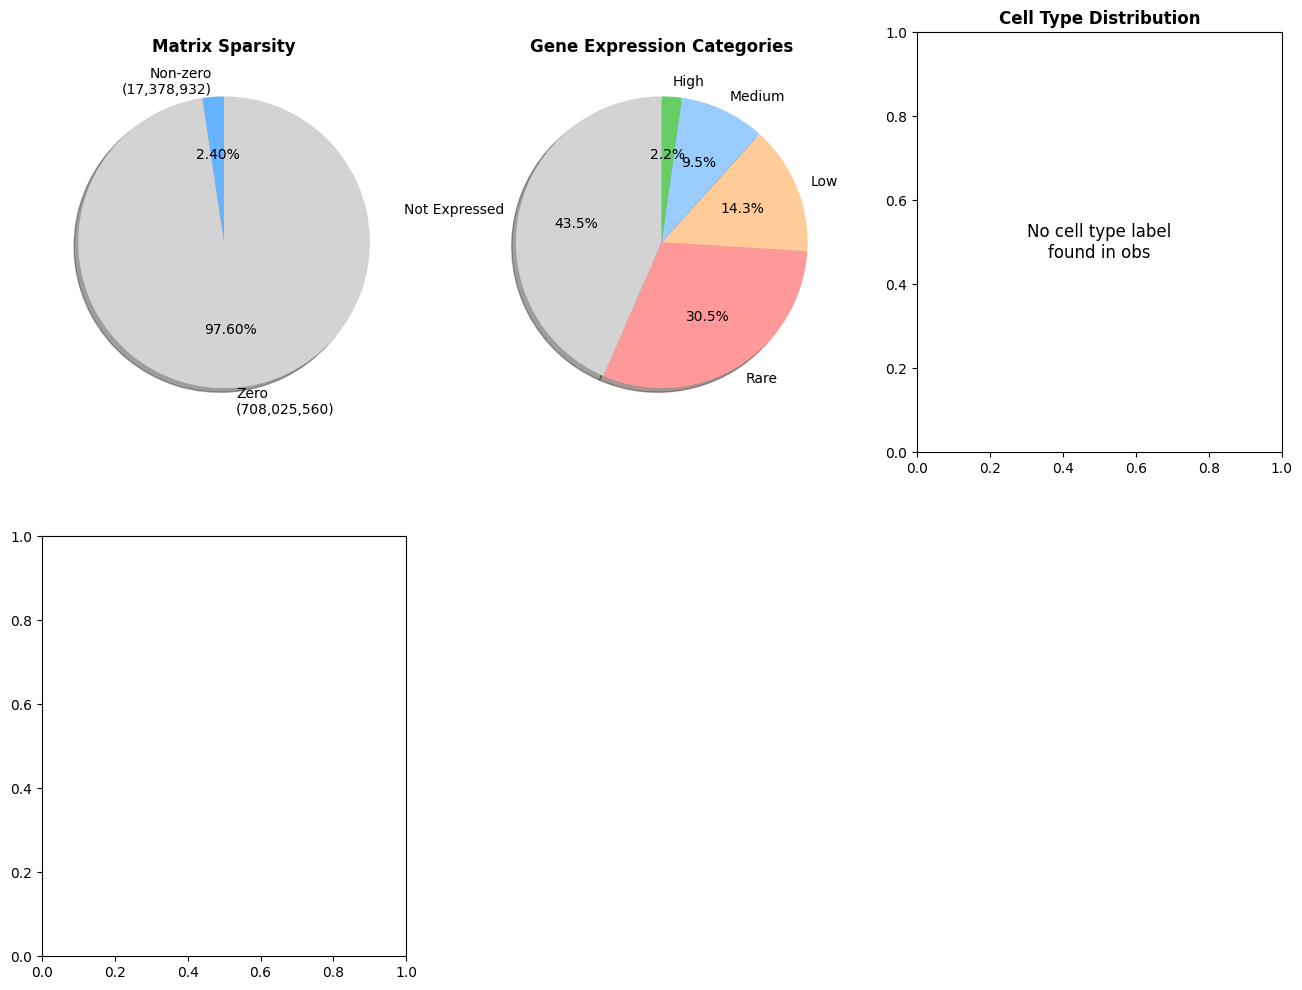

In [39]:
# 创建综合统计图
print("=" * 60)
print("📊 综合数据统计可视化")
print("=" * 60)

fig = plt.figure(figsize=(16, 12))

# 1. 稀疏度饼图
ax1 = fig.add_subplot(2, 3, 1)
nnz = X.nnz
zero_elements = adata.n_obs * adata.n_vars - nnz
sizes = [nnz, zero_elements]
labels = [f'Non-zero\n({nnz:,})', f'Zero\n({zero_elements:,})']
colors = ['#66b3ff', '#d3d3d3']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%',
        shadow=True, startangle=90)
ax1.set_title('Matrix Sparsity / 矩阵稀疏度', fontsize=12, fontweight='bold')

# 2. 基因分类饼图
ax2 = fig.add_subplot(2, 3, 2)
gene_cats = ['Not Expressed', 'Rare', 'Low', 'Medium', 'High']
gene_counts_pie = [not_expressed, rare_genes, low_genes, medium_genes, high_genes]
colors_pie = ['#d3d3d3', '#ff9999', '#ffcc99', '#99ccff', '#66cc66']
ax2.pie(gene_counts_pie, labels=gene_cats, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax2.set_title('Gene Expression Categories / 基因表达分类', fontsize=12, fontweight='bold')

# 3. 细胞类型分布
ax3 = fig.add_subplot(2, 3, 3)
if label_col:
    cell_type_counts = adata.obs[label_col].value_counts()
    top_types = cell_type_counts.head(15)
    ax3.barh(range(len(top_types)), top_types.values, color='steelblue')
    ax3.set_yticks(range(len(top_types)))
    ax3.set_yticklabels(top_types.index)
    ax3.set_xlabel('Cell Count / 细胞数量')
    ax3.set_title(f'Top 15 Cell Types\n({label_col})', fontsize=12, fontweight='bold')
    ax3.invert_yaxis()
else:
    ax3.text(0.5, 0.5, 'No cell type label\nfound in obs', ha='center', va='center',
             fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Cell Type Distribution / 细胞类型分布', fontsize=12, fontweight='bold')

# 4. n_counts vs n_genes 热力图
ax4 = fig.add_subplot(2, 3, 4)
n_counts_binned = pd.qcut(n_counts, q=20, labels=False, duplicates='drop')
n_genes_binned = pd.qcut(n_genes, q=20, labels=False, duplicates='drop')
heatmap_data = pd.crosstab(n_genes_binned, n_counts_binned)
sns.heatmap(heatmap_data, cmap='Blues', ax=ax4, cbar_kws={'label': 'Cell Count / 细胞数量'})
ax4.set_xlabel('Total Counts Bins (Q20) / 总表达量分箱(Q20)')
ax4.set_ylabel('Genes Detected Bins (Q20) / 检测基因数分箱(Q20)')
ax4.set_title('Cell Density: Counts vs Genes / 细胞密度:表达量vs基因数', fontsize=12, fontweight='bold')

# 5. 基因表达率分布直方图
ax5 = fig.add_subplot(2, 3, 5)
ax5.hist(gene_expr_rate * 100, bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
ax5.axvline(gene_expr_rate.mean() * 100, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {gene_expr_rate.mean()*100:.2f}%')
ax5.set_xlabel('Expression Rate (%) / 基因表达率(%)')
ax5.set_ylabel('Frequency / 频率')
ax5.set_title('Gene Expression Rate Distribution / 基因表达率分布', fontsize=12, fontweight='bold')
ax5.legend()

# 6. 累积分布函数
ax6 = fig.add_subplot(2, 3, 6)
sorted_expr_rate = np.sort(gene_expr_rate)
cdf = np.arange(1, len(sorted_expr_rate) + 1) / len(sorted_expr_rate)
ax6.plot(sorted_expr_rate * 100, cdf, 'b-', linewidth=2)
ax6.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax6.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
ax6.axhline(0.95, color='gray', linestyle='--', alpha=0.5)
ax6.set_xlabel('Expression Rate (%) / 基因表达率(%)')
ax6.set_ylabel('Cumulative Proportion of Genes / 基因累积比例')
ax6.set_title('CDF of Gene Expression Rate / 基因表达率累积分布函数', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step8_comprehensive_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: step8_comprehensive_stats.png")

In [ ]:
# 详细统计汇总表
print("\n📊 详细统计汇总表")
print("=" * 60)

summary_data = {
    'Metric': [
        'Total Cells',
        'Total Genes',
        'Matrix Size (cells × genes)',
        'Non-zero Elements',
        'Sparsity (%)',
        'Density (%)',
        'Total Counts (median per cell)',
        'Total Counts (mean per cell)',
        'Genes Detected (median per cell)',
        'Genes Detected (mean per cell)',
        'Genes Detected (min)',
        'Genes Detected (max)',
        'Gene Detection Rate (mean %)',
        'Not Expressed Genes',
        'Rare Genes (<1%)',
        'Low Expr Genes (1-5%)',
        'Medium Expr Genes (5-25%)',
        'High Expr Genes (>25%)',
    ],
    'Value': [
        f'{adata.n_obs:,}',
        f'{adata.n_vars:,}',
        f'{adata.n_obs * adata.n_vars:,}',
        f'{nnz:,}',
        f'{sparsity:.4f}',
        f'{density:.4f}',
        f'{np.median(n_counts):,.2f}',
        f'{n_counts.mean():,.2f}',
        f'{np.median(n_genes):,.0f}',
        f'{n_genes.mean():,.2f}',
        f'{n_genes.min():,}',
        f'{n_genes.max():,}',
        f'{gene_expr_rate.mean()*100:.4f}',
        f'{not_expressed:,}',
        f'{rare_genes:,}',
        f'{low_genes:,}',
        f'{medium_genes:,}',
        f'{high_genes:,}',
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

---

## Step 9: 总结报告 <a id="step9"></a>

In [ ]:
# 生成总结报告
print("=" * 70)
print("📋 数据集探索总结报告")
print("=" * 70)
print(f"""
文件路径: {DATA_PATH}
文件大小: {file_size / 1024**2:.2f} MB

【1. 基本信息】
────────────────────────────────────────────────────────────────────
  • 细胞数量:        {adata.n_obs:>15,} 个
  • 基因数量:        {adata.n_vars:>15,} 个
  • 矩阵维度:        {adata.n_obs:,} × {adata.n_vars:,} = {adata.n_obs * adata.n_vars:,} 个元素

【2. 稀疏度分析】
────────────────────────────────────────────────────────────────────
  • 矩阵类型:        {type(adata.X).__name__}
  • 非零元素数:      {X.nnz:>15,} 个
  • 稀疏度:          {sparsity:.4%} (即 {(sparsity*100):.2f}% 的元素为0)
  • 密度:            {density:.4%} (即 {(density*100):.2f}% 的元素非零)

【3. 细胞统计】
────────────────────────────────────────────────────────────────────
  • 每细胞平均表达量: {n_counts.mean():>15,.2f}
  • 每细胞中位表达量: {np.median(n_counts):>15,.2f}
  • 每细胞平均检测基因数: {n_genes.mean():>10,.0f} 个
  • 每细胞中位检测基因数: {np.median(n_genes):>10,.0f} 个
  • 平均基因检测率: {n_genes.mean()/adata.n_vars*100:.2f}%

【4. 基因统计】
────────────────────────────────────────────────────────────────────
  • 未表达基因数:    {not_expressed:>15,} 个 ({(not_expressed/adata.n_vars*100):.2f}%)
  • 稀有基因 (<1%):  {rare_genes:>15,} 个 ({(rare_genes/adata.n_vars*100):.2f}%)
  • 低表达 (1-5%):  {low_genes:>15,} 个 ({(low_genes/adata.n_vars*100):.2f}%)
  • 中表达 (5-25%): {medium_genes:>15,} 个 ({(medium_genes/adata.n_vars*100):.2f}%)
  • 高表达 (>25%):  {high_genes:>15,} 个 ({(high_genes/adata.n_vars*100):.2f}%)

【5. obs (细胞元数据)】
────────────────────────────────────────────────────────────────────
  • obs 列数:        {len(adata.obs.columns)}
  • obs 列名:        {list(adata.obs.columns)}

【6. var (基因元数据)】
────────────────────────────────────────────────────────────────────
  • var 列数:        {len(adata.var.columns)}
  • var 列名:        {list(adata.var.columns)}

【7. obsm (降维嵌入)】
────────────────────────────────────────────────────────────────────
  • 可用嵌入:        {list(adata.obsm.keys()) if adata.obsm else '无'}

【8. uns (非结构化数据)】
────────────────────────────────────────────────────────────────────
  • uns 键:          {list(adata.uns.keys()) if adata.uns else '无'}
""")

print("=" * 70)
print("✅ 数据探索完成!")
print("=" * 70)

In [ ]:
# 保存报告到文件
report_path = 'dataset_exploration_report.txt'
with open(report_path, 'w') as f:
    f.write(f"数据集探索报告: SRP182008.h5ad\n")
    f.write(f"{'=' * 60}\n\n")
    f.write(f"基本维度: {adata.n_obs:,} cells × {adata.n_vars:,} genes\n")
    f.write(f"矩阵类型: {type(adata.X).__name__}\n")
    f.write(f"稀疏度: {sparsity:.4%}\n")
    f.write(f"非零元素数: {X.nnz:,}\n")
    f.write(f"每细胞中位表达量: {np.median(n_counts):,.2f}\n")
    f.write(f"每细胞中位基因数: {np.median(n_genes):,.0f}\n")
    f.write(f"\nobs 列: {list(adata.obs.columns)}\n")
    f.write(f"var 列: {list(adata.var.columns)}\n")
    f.write(f"obsm 嵌入: {list(adata.obsm.keys())}\n")
    f.write(f"\n基因分类:\n")
    f.write(f"  未表达: {not_expressed:,} ({(not_expressed/adata.n_vars*100):.2f}%)\n")
    f.write(f"  稀有 (<1%): {rare_genes:,} ({(rare_genes/adata.n_vars*100):.2f}%)\n")
    f.write(f"  低表达 (1-5%): {low_genes:,} ({(low_genes/adata.n_vars*100):.2f}%)\n")
    f.write(f"  中表达 (5-25%): {medium_genes:,} ({(medium_genes/adata.n_vars*100):.2f}%)\n")
    f.write(f"  高表达 (>25%): {high_genes:,} ({(high_genes/adata.n_vars*100):.2f}%)\n")

print(f"📄 报告已保存到: {report_path}")

---

## 附录: 如何将此 notebook 用于其他 h5ad 文件

只需要修改顶部的 `DATA_PATH` 变量即可:

```python
DATA_PATH = "/path/to/your/data.h5ad"
```

所有后续分析代码都会自动适应新的数据集。

### 常用 h5ad 数据路径参考:
```python
DATA_PATH = "/data/luolie/biopipeline/scCluBench/data/SRP171040.h5ad"
DATA_PATH = "/data/luolie/biopipeline/scCluBench/data/PRJNA895163.h5ad"
```